# Elliptic Dataset: Leakage Investigation

Is there evidence or data leakage?

This project investigates whether the Elliptic dataset is robust or contains potential data leakage before proceeding to downstream modeling.

## Content

Here are the three datasets described in “*Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks for Financial Forensics*” by Weber, Domeniconi, Chen, Weidele, Bellei, Robinson, and Leiserson and it is worth repeating.

### `classes`

This anonymized data set is a transaction graph collected from the Bitcoin blockchain. A node in the graph represents a transaction, an edge can be viewed as a flow of Bitcoins between one transaction and the other. Each node has 166 features and has been labeled as being created by a "licit", "illicit" or "unknown" entity.

## Nodes and edges

### `edgelist`

The graph is made of 203,769 nodes and 234,355 edges. Two percent (4,545) of the nodes are labelled class1 (illicit). Twenty-one percent (42,019) are labelled class2 (licit). The remaining transactions are not labelled with regard to licit versus illicit.

## Features

### `features`

There are 166 features associated with each node. Due to intellectual property issues, we cannot provide an exact description of all the features in the dataset. There is a time step associated to each node, representing a measure of the time when a transaction was broadcasted to the Bitcoin network. The time steps, running from 1 to 49, are evenly spaced with an interval of about two weeks. Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.

The first 94 features represent local information about the transaction – including the time step described above, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features are aggregated features, obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbour transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

from scipy.stats import spearmanr, ks_2samp

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [ ]:
# Mount the data set
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3 data sets: Content, nodes and edges, and features.
df_classes = pd.read_csv('/content/drive/MyDrive/elliptic_txs_classes.csv')
df_edgelist = pd.read_csv('/content/drive/MyDrive/elliptic_txs_edgelist.csv')
# need a header
df_features = pd.read_csv('/content/drive/MyDrive/elliptic_txs_features.csv', header=None)


In [ ]:
df_classes

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown
...,...,...
203764,173077460,unknown
203765,158577750,unknown
203766,158375402,1
203767,158654197,unknown


In [ ]:
# '1' and '2' are objects so let's convert it
df_classes['class'] = pd.to_numeric(df_classes['class'], errors='coerce')

# using .map for 1-illict and 2-licit
# leave the 'unknown' using .fillna
df_classes['class'] = df_classes['class'].map({1: 'illicit', 2: 'licit'}).fillna('unknown')

In [ ]:
# How many count?
df_classes['class'].value_counts(1)

,proportion
class,
unknown,0.771486
licit,0.206209
illicit,0.022305


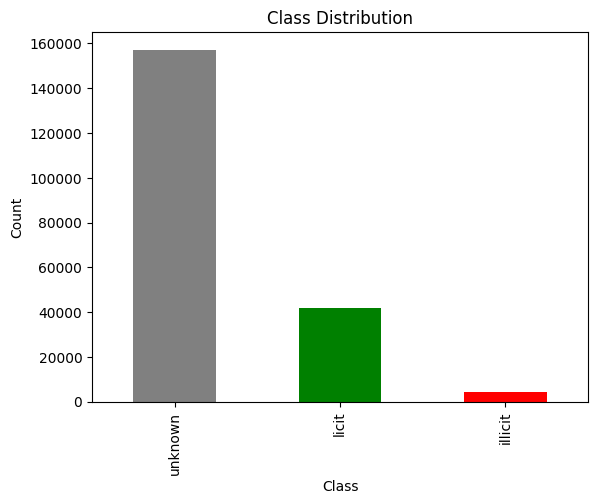

In [ ]:
# visual for df_classes using values counts().plot, ad kind='bar'
# illicit = red, and licit = green, unknow = gray

df_classes['class'].value_counts().plot(kind='bar', title='Class Distribution', color=['gray', 'green', 'red'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# Let's change the features from txId1 is the source and txId2 is the target
df_edgelist = df_edgelist.rename(columns = {'txId1':'source', 'txId2':'target'})



In [ ]:
df_edgelist

,source,target
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [ ]:
df_features

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.162722,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.261246,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.397749,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399


In [ ]:
df_features.columns


Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166],
      dtype='int64', length=167)

In [ ]:
print(df_features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 167 entries, 0 to 166
dtypes: float64(165), int64(2)
memory usage: 259.6 MB
None


## Temporal Split

To reduce temporal leakage, I used a strict chronological split based on the `time_step` variable. Since the Elliptic dataset represents transaction activity evolving over time, random train-test splits could allow future transaction behavior to leak into the training process.

The split was defined as:

- Training: time steps 1–34
- Validation: time steps 35–39
- Test: time steps 40–49

This setup better simulates a real-world fraud detection scenario where models are trained on historical transaction behavior and evaluated on future unseen activity.

In [ ]:
# rename class = label
df_classes = df_classes.rename(columns={'class': 'label'})

# rename feature colunms for clarity
df_features = df_features.rename(columns={0: 'txId', 1: 'time_step'})

# merge labels into df_features splitting
df_features = df_features.merge(df_classes[['txId', 'label']], on='txId', how='left')

# Temporal Split
train_df = df_features[df_features['time_step'] <= 34].copy()

val_df = df_features[(df_features['time_step'] >= 35) &
                     (df_features['time_step'] <= 39)].copy()

test_df = df_features[df_features['time_step'] >= 40].copy()

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print(train_df["time_step"].min(), train_df["time_step"].max())
print(val_df["time_step"].min(), val_df["time_step"].max())
print(test_df["time_step"].min(), test_df["time_step"].max())

(136265, 168)
(20857, 168)
(46647, 168)
1 34
35 39
40 49


The resulting split sizes were:

- Training set: 136,265 transactions
- Validation set: 20,857 transactions
- Test set: 46,647 transactions

This preserved the chronological ordering of the transaction graph while providing sufficient data for training and evaluation. Furthermore, the temporal split better reflects real-world fraud detection settings, where models must generalize from historical transaction patterns to future unseen activity.

In [ ]:
# Count the number of transaction nodes in each temporal snapshot.
# Each time_step represents a snapshot of the Bitcoin transaction graph.
df_features['time_step'].value_counts().sort_index()

,count
time_step,
1,7880
42,7140
5,6803
10,6727
3,6621
36,6393
7,6048
22,5894
4,5693


## Logistic Regression Baseline

This section presents a baseline logistic regression model using all 166 features from the Elliptic dataset. The goal is to establish an initial benchmark before investigating potential temporal leakage and feature robustness.

In [ ]:
# define feature columns
feature_cols = [c for c in df_features.columns
                if c not in ['txId', 'time_step', 'label']
]

print(len(feature_cols))

165


In [ ]:
train_df.columns

Index([     'txId', 'time_step',           2,           3,           4,
                 5,           6,           7,           8,           9,
       ...
               158,         159,         160,         161,         162,
               163,         164,         165,         166,     'label'],
      dtype='object', length=168)

In [ ]:
# Now, filter out 'unknown' labels
train_df = train_df[train_df['label'] != 'unknown'].copy()
val_df = val_df[val_df['label'] != 'unknown'].copy()
test_df = test_df[test_df['label'] != 'unknown'].copy()

In [ ]:
# create X and y
X_train = train_df[feature_cols]
y_train = train_df['label']

X_val = val_df[feature_cols]
y_val = val_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

In [ ]:
# train model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# validation predictions
val_preds = lr_model.predict(X_val)

# evaluate
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

     illicit       0.27      0.95      0.42       447
       licit       0.99      0.77      0.87      5039

    accuracy                           0.78      5486
   macro avg       0.63      0.86      0.64      5486
weighted avg       0.94      0.78      0.83      5486



The logistic regression classifier achieved a validation accuracy of 0.78. The validation F1-score for illicit transactions was 0.42, while the F1-score for licit transactions was 0.87. Overall, the model appears reasonably stable and does not immediately suggest severe leakage, although further leakage diagnostics are still necessary.


## Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200,
                                  max_depth=None,
                                  min_samples_leaf=2,
                                  class_weight = 'balanced',
                                  random_state=42,
                                  n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# validation
rf_val_preds = rf_model.predict(X_val)
print(classification_report(y_val, rf_val_preds))

rf_val_f1 = f1_score(y_val, rf_val_preds, pos_label='illicit')
print('Random Forest Validation Illicit F1', rf_val_f1)

              precision    recall  f1-score   support

     illicit       0.98      0.91      0.94       447
       licit       0.99      1.00      1.00      5039

    accuracy                           0.99      5486
   macro avg       0.99      0.95      0.97      5486
weighted avg       0.99      0.99      0.99      5486

Random Forest Validation Illicit F1 0.9441860465116279


In [ ]:
f1 = f1_score(y_val, val_preds, pos_label='illicit')
print('Logistic Regression Validation F1:', f1)
print('Random Forest Validation F1:', rf_val_f1)

Logistic Regression Validation F1: 0.41723800195886385
Random Forest Validation F1: 0.9441860465116279


The Random Forest baseline achieved a validation accuracy of 0.99, with an illicit transaction F1-score of 0.94. This performance is extremely high and raises suspicion of potential leakage or strong temporal feature encoding. Therefore, the next phase of the investigation will restrict the analysis to local features (2–95) to evaluate whether the model remains robust under reduced temporal information.

# Local feature 2 to 95

In [ ]:
# local feature
local_feature_cols = df_features.columns[2:96]

In [ ]:
# oops! 95 vs 96
print(df_features.columns[2:96])

Index([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
       38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
       74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91,
       92, 93, 94],
      dtype='object')


In [ ]:
X_train_local = train_df[local_feature_cols]
X_val_local = val_df[local_feature_cols]
X_test_local = test_df[local_feature_cols]

y_train_local = train_df['label']
y_val_local = val_df['label']
y_test_local = test_df['label']

In [ ]:
# Logistic Regression
lr_local = LogisticRegression(max_iter=1000)
lr_local.fit(X_train_local, y_train_local)

val_pred_lr_local = lr_local.predict(X_val_local)

f1_lr_local = f1_score(y_val_local, val_pred_lr_local, pos_label='illicit')

# Random Forest
rf_local = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_local.fit(X_train_local, y_train_local)

val_pred_rf_local = rf_local.predict(X_val_local)

f1_rf_local = f1_score(y_val_local, val_pred_rf_local, pos_label='illicit')

print("Local Logistic Regression F1:", f1_lr_local)
print("Local Random Forest F1:", f1_rf_local)

# evaluate local
print(classification_report(y_val_local, val_pred_rf_local))

Local Logistic Regression F1: 0.6360759493670886
Local Random Forest F1: 0.9220183486238532
              precision    recall  f1-score   support

     illicit       0.95      0.90      0.92       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.97      0.95      0.96      5486
weighted avg       0.99      0.99      0.99      5486



The Logistic Regression model achieved an illicit transaction F1-score of 0.64, while the Random Forest achieved an F1-score of 0.92 using only local features (2–95). Although the performance decreased slightly after removing the broader feature set, the Random Forest still remains suspiciously strong. This suggests that additional leakage investigation and robustness testing are still necessary, particularly for the Random Forest model.

In [ ]:
if 'rf_local' in locals():
    max_depths = [estimator.tree_.max_depth for estimator in rf_local.estimators_]
    print(f"The maximum depth was: {max(max_depths)}")
else:
    print("Please re-run the relevant cells to make it available.")

The maximum depth for individual trees in the first rf_local model (where max_depth was None) was: 29


## Only focus on 96 to 166

In [ ]:
aggregated_features_cols = df_features.columns[96:167]

X_train_aggregated = train_df[aggregated_features_cols]
X_val_aggregated = val_df[aggregated_features_cols]
X_test_aggregated = test_df[aggregated_features_cols]

y_train_aggregated = train_df["label"]
y_val_aggregated = val_df["label"]
y_test_aggregated = test_df["label"]

# random forest
rf_aggregated = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs = -1
)

rf_aggregated.fit(X_train_aggregated, y_train_aggregated)

val_pred_rf_aggregated = rf_aggregated.predict(X_val_aggregated)

f1_rl_aggregated = f1_score(y_val_aggregated, val_pred_rf_aggregated, pos_label = "illicit")

print(classification_report(y_val_aggregated, val_pred_rf_aggregated))

              precision    recall  f1-score   support

     illicit       0.93      0.65      0.77       447
       licit       0.97      1.00      0.98      5039

    accuracy                           0.97      5486
   macro avg       0.95      0.82      0.88      5486
weighted avg       0.97      0.97      0.97      5486



#### Check Class Balance

In [ ]:
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())

label
licit      26432
illicit     3462
Name: count, dtype: int64
label
licit      5039
illicit     447
Name: count, dtype: int64


The dataset is highly imbalanced, with licit transactions greatly outnumbering illicit transactions in both the training and validation sets. This imbalance is important because high accuracy alone may be misleading, making the illicit F1-score a more informative metric for evaluation.


#### Verify Feature Ranges

In [ ]:
print(train_df['time_step'].min(), train_df['time_step'].max())
print(val_df['time_step'].min(), val_df['time_step'].max())

1 34
35 39


The feature ranges confirm that the temporal split was applied correctly. The training set contains time steps 1–34, while the validation set contains time steps 35–39. This separation helps reduce direct temporal leakage between training and validation data.

### Random Forest Feature Inspection

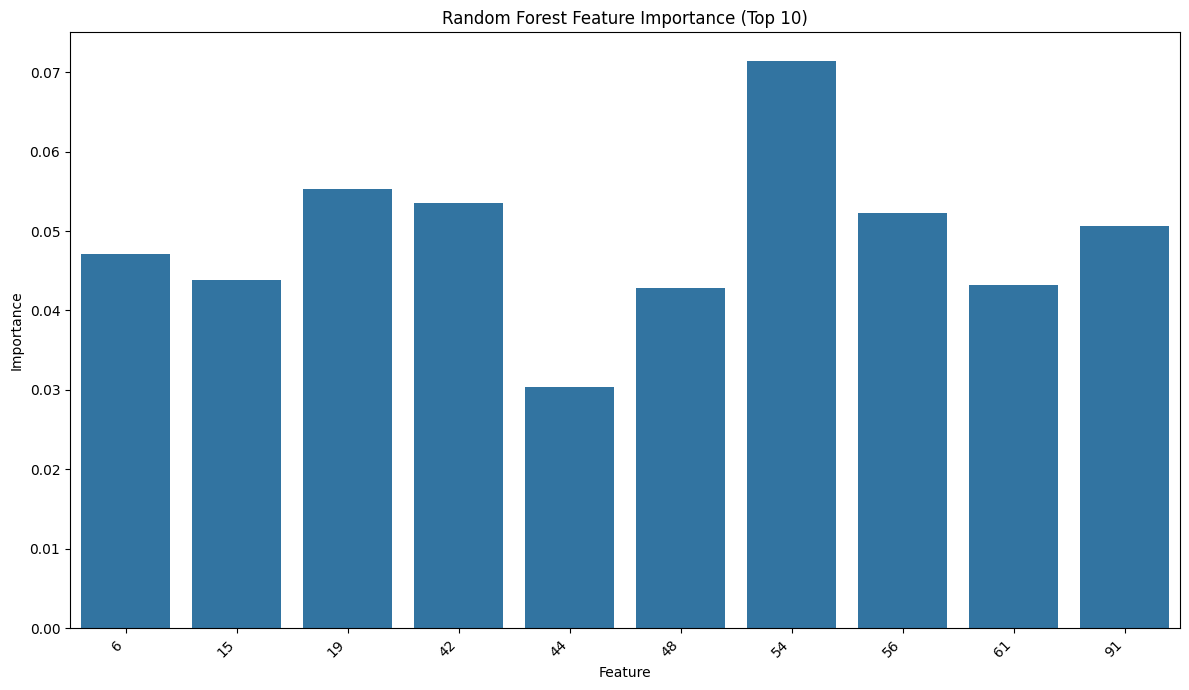

In [ ]:
importance_df = pd.DataFrame({
    'feature': local_feature_cols,
    'importance': rf_local.feature_importances_
})

importance_df = importance_df.sort_values('importance', ascending=False)

top_features_df = importance_df.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(y='importance', x='feature', data=top_features_df)
plt.title('Random Forest Feature Importance (Top 10)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
importance_df.head(10)

,feature,importance
52,54,0.066725
40,42,0.048653
54,56,0.045911
89,91,0.043692
17,19,0.042679
4,6,0.041095
46,48,0.037354
59,61,0.037242
13,15,0.035984
42,44,0.030333


The Random Forest feature importances appear relatively distributed and do not show a single overwhelmingly dominant feature. The top features remain within a moderate importance range, which suggests the model is not relying entirely on one isolated variable. However, despite the more balanced feature importance profile, the unusually high model performance still warrants additional leakage and robustness investigation.

### Wider temporal gap

In [ ]:
# Temporal Split Gap

train_df = df_features[df_features['time_step'] <= 25].copy()

val_df = df_features[(df_features['time_step'] >= 35) &
                     (df_features['time_step'] <= 39)].copy()

test_df = df_features[df_features['time_step'] >= 45].copy()

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print(train_df["time_step"].min(), train_df["time_step"].max())
print(val_df["time_step"].min(), val_df["time_step"].max())
print(test_df["time_step"].min(), test_df["time_step"].max())

(111264, 168)
(20857, 168)
(19646, 168)
1 25
35 39
45 49


In [ ]:
train_df = train_df[train_df['label'] != 'unknown'].copy()
val_df = val_df[val_df['label'] != 'unknown'].copy()
test_df = test_df[test_df['label'] != 'unknown'].copy()

print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

label
licit      21863
illicit     2337
Name: count, dtype: int64
label
licit      5039
illicit     447
Name: count, dtype: int64
label
licit      3605
illicit     121
Name: count, dtype: int64


In [ ]:
X_train_local = train_df[local_feature_cols]
X_val_local = val_df[local_feature_cols]
X_test_local = test_df[local_feature_cols]

y_train_local = train_df['label']
y_val_local = val_df['label']
y_test_local = test_df['label']

In [ ]:
# Logistic Regression
lr_local = LogisticRegression(max_iter=1000)

lr_local.fit(X_train_local, y_train_local)

val_pred_lr_local = lr_local.predict(X_val_local)

f1_lr_local = f1_score(
    y_val_local,
    val_pred_lr_local,
    pos_label='illicit'
)

# Random Forest
rf_local = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_local.fit(X_train_local, y_train_local)

val_pred_rf_local = rf_local.predict(X_val_local)

f1_rf_local = f1_score(
    y_val_local,
    val_pred_rf_local,
    pos_label='illicit'
)

print("Local Logistic Regression F1:", f1_lr_local)
print("Local Random Forest F1:", f1_rf_local)

print(classification_report(y_val_local, val_pred_rf_local))

Local Logistic Regression F1: 0.4938875305623472
Local Random Forest F1: 0.9181084198385236
              precision    recall  f1-score   support

     illicit       0.95      0.89      0.92       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.97      0.94      0.96      5486
weighted avg       0.99      0.99      0.99      5486



Using a wider temporal gap, the local Logistic Regression F1-score dropped substantially to approximately 0.49, suggesting that the model struggles to generalize when stronger temporal separation is enforced. In contrast, the Random Forest F1-score decreased only slightly to approximately 0.92.

This relatively stable Random Forest performance, even under a wider temporal gap, remains suspicious and suggests that some form of temporal structure or indirect leakage may still be present in the local features. Although the wider temporal split reduces direct leakage risk, the Random Forest model may still be capturing patterns that strongly encode time-dependent behavior.

#### Shuffle Labels

In [ ]:
y_train_shuffled = np.random.permutation(y_train_local)

rf_shuffle = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_shuffle.fit(X_train_local, y_train_shuffled)

shuffle_pred = rf_shuffle.predict(X_val_local)

shuffle_f1 = f1_score(
    y_val_local,
    shuffle_pred,
    pos_label='illicit'
)

print('Shuffled-lablel RF F1', shuffle_f1)
print(classification_report(y_val_local, shuffle_pred))

Shuffled-lablel RF F1 0.0
              precision    recall  f1-score   support

     illicit       0.00      0.00      0.00       447
       licit       0.92      1.00      0.96      5039

    accuracy                           0.92      5486
   macro avg       0.46      0.50      0.48      5486
weighted avg       0.84      0.92      0.88      5486



The shuffled-label Random Forest produced an illicit transaction F1-score of 0.0. This is a good sign, as the model completely failed once the labels were randomly scrambled. Since the temporal structure between the features and labels was destroyed, the model could no longer learn meaningful predictive patterns.

This suggests that the Random Forest is not simply memorizing the validation labels directly, and the shuffle-label test does not provide strong evidence of direct leakage.



## Random Feature Importance

Inspect the top Random Forest feature importances and evaluate their distributions across the train, validation, and test windows. The goal is to determine whether significant temporal distribution shifts are present.

In [ ]:
rf_local.feature_importances_

array([0.00536139, 0.03569905, 0.00412141, 0.00787243, 0.04739218,
       0.0115757 , 0.00010916, 0.0121328 , 0.00541218, 0.01215699,
       0.00470678, 0.00151601, 0.00129269, 0.03779702, 0.        ,
       0.00925302, 0.00624282, 0.05483136, 0.00345374, 0.0049468 ,
       0.00201461, 0.00596168, 0.01653565, 0.00458825, 0.00965288,
       0.00151811, 0.00113141, 0.01071612, 0.02254083, 0.00645207,
       0.0142011 , 0.00104789, 0.00085881, 0.00029022, 0.0006444 ,
       0.00037962, 0.00063763, 0.00014705, 0.00020319, 0.0074962 ,
       0.0512971 , 0.00171921, 0.02920121, 0.00064957, 0.00045451,
       0.00486081, 0.04223094, 0.00957092, 0.02495606, 0.00080787,
       0.00056967, 0.02295041, 0.06343369, 0.01073242, 0.04766207,
       0.00151131, 0.00134765, 0.01217239, 0.00832355, 0.03940889,
       0.00807188, 0.00215527, 0.00213512, 0.01262065, 0.00661978,
       0.02464442, 0.00705574, 0.0011107 , 0.00061379, 0.00013579,
       0.00320862, 0.00345728, 0.00412436, 0.00119435, 0.00099

In [ ]:
importance_df = pd.DataFrame({
    'feature': local_feature_cols,
    'importance': rf_local.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
importance_df.head(20)

,feature,importance
52,54,0.071442
17,19,0.055267
40,42,0.053470
54,56,0.052291
89,91,0.050586
4,6,0.047143
13,15,0.043854
59,61,0.043234
46,48,0.042859
42,44,0.030420


The Random Forest feature importances were inspected to identify which variables had the strongest influence on the model’s predictions. The most influential features were 56, 48, and 54.

The next step is to plot these top features across the train, validation, and test windows to check whether their distributions shift over time. This will help determine whether the Random Forest is learning stable fraud-related patterns or relying on temporal structure.

## Plot Important Features Across Time

The top Random Forest feature importances were inspected and plotted across the train, validation, and test time windows to investigate potential temporal leakage or distribution shift.

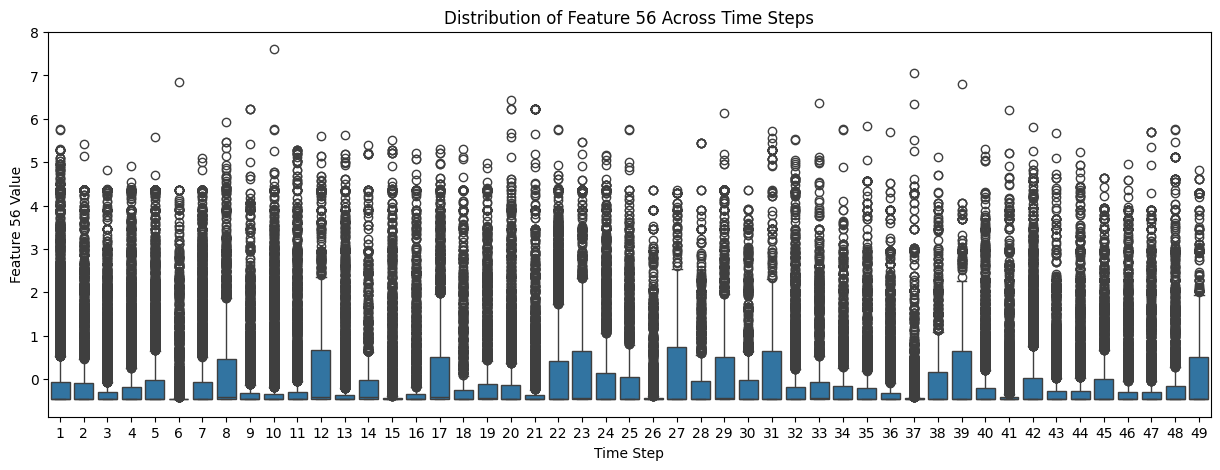

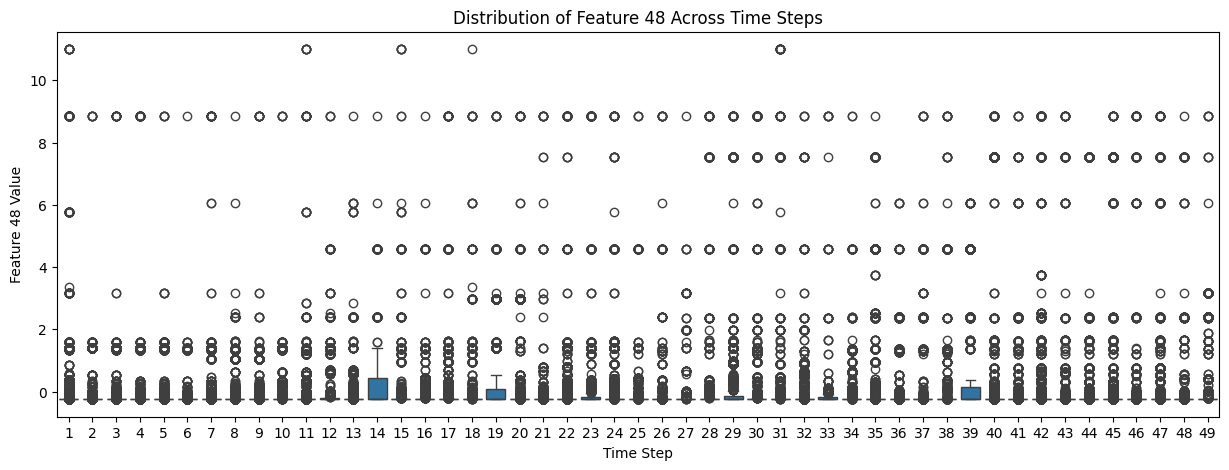

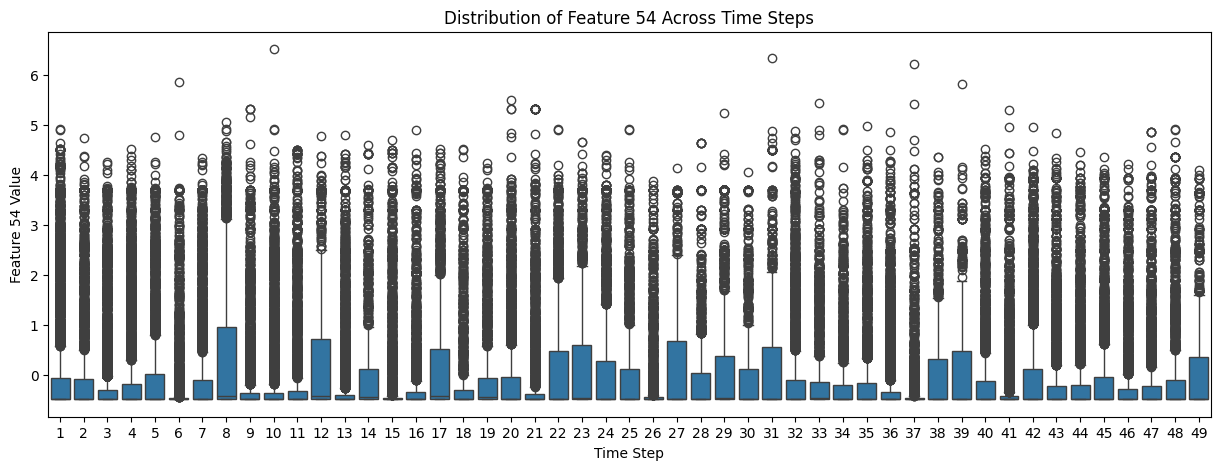

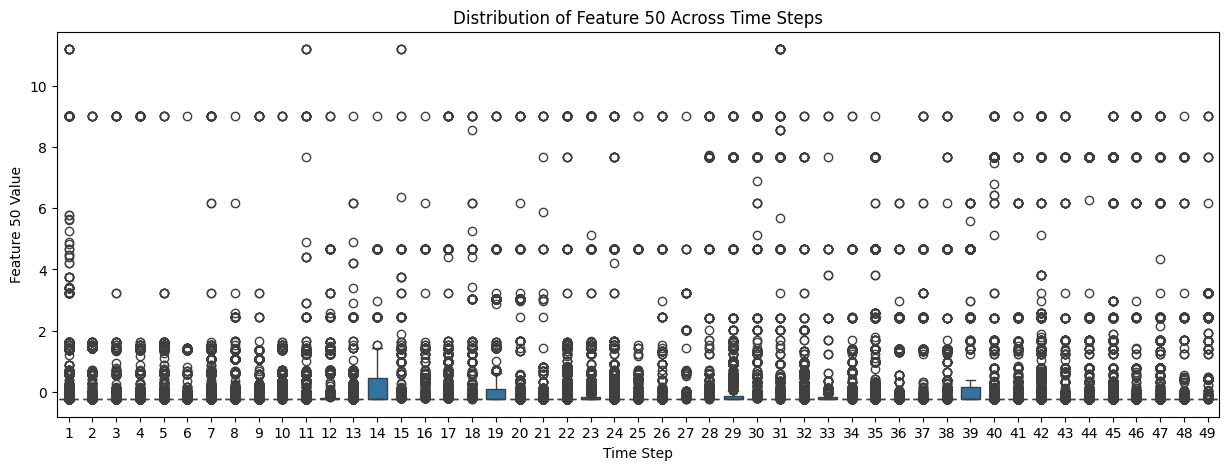

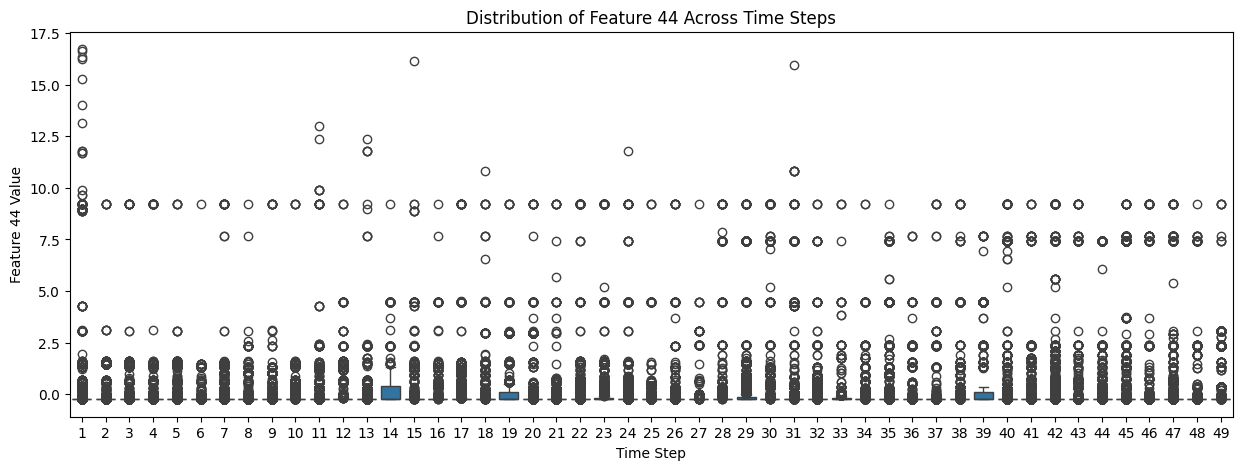

In [ ]:
features_to_plot = [56, 48, 54, 50, 44]

for feature in features_to_plot:
    plt.figure(figsize=(15, 5))
    sns.boxplot(x='time_step', y=feature, data=df_features)
    plt.title(f'Distribution of Feature {feature} Across Time Steps')
    plt.xlabel('Time Step')
    plt.ylabel(f'Feature {feature} Value')
    plt.show()

After reviewing the top important features, the distributions appear relatively stable across time. The plotted features do not show strong monotonic drift, sudden jumps between temporal windows, or clear separation by time blocks.

Instead, the features exhibit:

- noisy distributions,
- fairly stable ranges,
- occasional outliers,
- and generally similar shapes across time steps.

These observations weaken the hypothesis that the Random Forest is directly learning or exploiting simple temporal leakage through these top features. However, additional diagnostics are still necessary because the overall model performance remains unusually strong.

## Confusion Matrix

The confusion matrix was examined alongside the classification report to better understand the model’s prediction behavior under class imbalance.

In [ ]:
# TN, FP
# FN, TP
cm = confusion_matrix(y_val_local, val_pred_rf_local)
print(cm)

[[ 398   49]
 [  22 5017]]


In [ ]:
# report
print(classification_report(y_val_local, val_pred_rf_local))

              precision    recall  f1-score   support

     illicit       0.95      0.89      0.92       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.97      0.94      0.96      5486
weighted avg       0.99      0.99      0.99      5486



In [ ]:
# Recall = TP/(TP+FN)
5017/(5017+22)

0.9956340543758683

In [ ]:
# Precision = TP/(TP+FP)
5017/(5017+49)

0.9903276746940387

The Random Forest achieved very high performance on the validation set, with:

- licit precision near 0.99,
- licit recall near 1.00,
- and overall accuracy of 0.99.

The confusion matrix also shows relatively few false positives and false negatives, indicating that the model is classifying most transactions correctly.

## Shallower Trees

To further investigate potential leakage and model complexity, Random Forest performance was evaluated across multiple tree depths. The goal was to determine whether the model relied on overly complex decision boundaries or whether the local transaction statistics themselves contained meaningful predictive structure.

In [ ]:
# Random Forest
rf_local = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

rf_local.fit(X_train_local, y_train_local)

val_pred_rf_local = rf_local.predict(X_val_local)

f1_rf_local = f1_score(
    y_val_local,
    val_pred_rf_local,
    pos_label='illicit'
)

print("Local Random Forest F1:", f1_rf_local)
print(classification_report(y_val_local, val_pred_rf_local))

Local Random Forest F1: 0.8841843088418431
              precision    recall  f1-score   support

     illicit       1.00      0.79      0.88       447
       licit       0.98      1.00      0.99      5039

    accuracy                           0.98      5486
   macro avg       0.99      0.90      0.94      5486
weighted avg       0.98      0.98      0.98      5486



In [ ]:
# Random Forest
rf_local = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_local.fit(X_train_local, y_train_local)

val_pred_rf_local = rf_local.predict(X_val_local)

f1_rf_local = f1_score(
    y_val_local,
    val_pred_rf_local,
    pos_label='illicit'
)

print("Local Random Forest F1:", f1_rf_local)

Local Random Forest F1: 0.8883374689826302


In [ ]:
# Random Forest
rf_local = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_local.fit(X_train_local, y_train_local)

val_pred_rf_local = rf_local.predict(X_val_local)

f1_rf_local = f1_score(
    y_val_local,
    val_pred_rf_local,
    pos_label='illicit'
)

print("Local Random Forest F1:", f1_rf_local)

Local Random Forest F1: 0.9284876905041032


The results were:

- `max_depth = 3` → F1 = 0.8841
- `max_depth = 5` → F1 = 0.8883
- `max_depth = 10` → F1 = 0.9285

Even relatively shallow trees achieved strong performance, while deeper trees improved performance gradually rather than producing a sudden jump in F1-score. This behavior suggests that the model is likely learning genuine nonlinear structure from the local transaction statistics rather than relying on trivial memorization or a single dominant leakage feature.



## Single Decision Tree


In [ ]:
# single decision tree
dt_local = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

dt_local.fit(X_train_local, y_train_local)

val_pred_dt_local = dt_local.predict(X_val_local)

print("validaton F1:", f1_score(y_val_local, val_pred_dt_local, pos_label='illicit'))
print(classification_report(y_val_local, val_pred_dt_local))

validaton F1: 0.17843710823234435
              precision    recall  f1-score   support

     illicit       0.10      0.96      0.18       447
       licit       0.98      0.22      0.36      5039

    accuracy                           0.28      5486
   macro avg       0.54      0.59      0.27      5486
weighted avg       0.91      0.28      0.35      5486



#### Decision Tree Rule Inspection

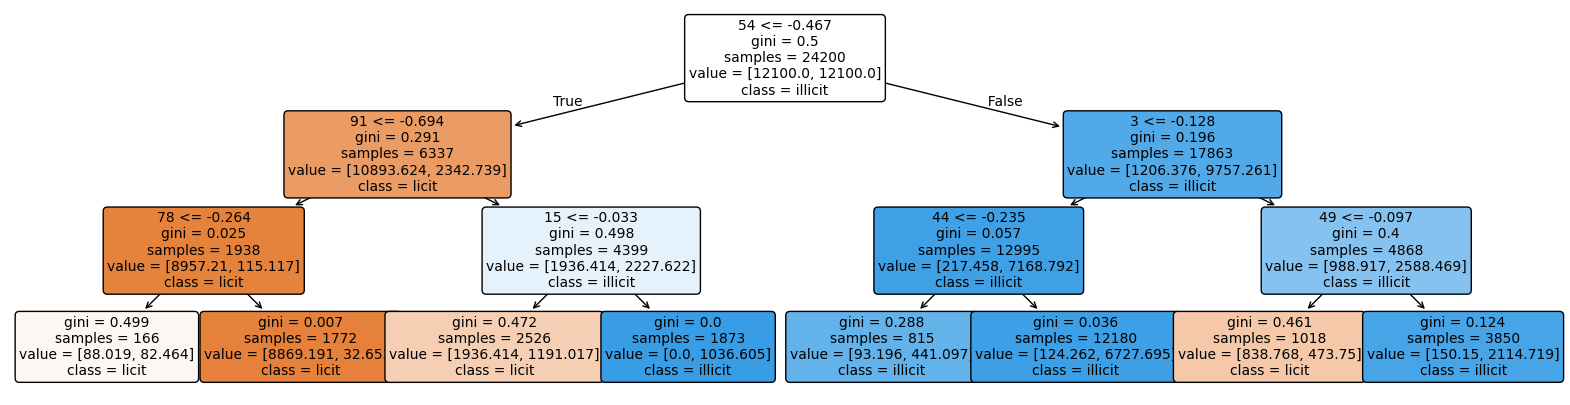

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,5))
plot_tree(
    dt_local,
    feature_names=feature_cols,
    class_names=['licit', 'illicit'],
    filled=True,
    rounded=True,
    fontsize=10

)

plt.show()

#### Extracted Decison Rules

In [ ]:
rules = export_text(dt_local,
                    feature_names=list(X_train_local.columns))
print(rules)

|--- 54 <= -0.47
|   |--- 91 <= -0.69
|   |   |--- 78 <= -0.26
|   |   |   |--- class: illicit
|   |   |--- 78 >  -0.26
|   |   |   |--- class: illicit
|   |--- 91 >  -0.69
|   |   |--- 15 <= -0.03
|   |   |   |--- class: illicit
|   |   |--- 15 >  -0.03
|   |   |   |--- class: licit
|--- 54 >  -0.47
|   |--- 3 <= -0.13
|   |   |--- 44 <= -0.23
|   |   |   |--- class: licit
|   |   |--- 44 >  -0.23
|   |   |   |--- class: licit
|   |--- 3 >  -0.13
|   |   |--- 49 <= -0.10
|   |   |   |--- class: illicit
|   |   |--- 49 >  -0.10
|   |   |   |--- class: licit



The shallow decision tree was used as an interpretable diagnostic model with temporally separated training and validation sets. The goal was not to maximize performance, but to inspect whether the classifier relied on suspicious or potentially leaky features. The tree recursively partitions the feature space using threshold-based splits that reduce class impurity (Gini impurity).

Feature 54 produced the strongest initial split, suggesting that this anonymized transaction statistic contains useful information for separating licit and illicit transactions. Because the Elliptic dataset anonymizes its features, additional caution is required when interpreting feature importance, since highly predictive features could potentially encode temporal or structural leakage.

## Time Correlation Test


I chose Spearman correlation because I wanted to detect monotonic temporal structure between features and `time_step` without assuming linearity or normality. Since fraud transaction behavior and graph-derived features may evolve nonlinearly over time, a rank-based statistic was more appropriate than Pearson correlation.

### Spearman Correlation Test

In [ ]:

local_feature_cols = df_features.columns[2:95].tolist()

results = []

for col in local_feature_cols:

  corr, pval = spearmanr(df_features[col], df_features['time_step'])

  results.append({
      'feature': col,
      'spearman_corr': corr,
      'p_value': pval,
      'abs_corr': abs(corr)
  })

corr_df = pd.DataFrame(results)

# sort by strongest correlation
corr_df = corr_df.sort_values('abs_corr', ascending=False)

# Display p_value decimal places
with pd.option_context('display.float_format', '{:.4f}'.format):
  display(corr_df.head(10))

,feature,spearman_corr,p_value,abs_corr
1,3,0.6309,0.0000,0.6309
2,4,0.5578,0.0000,0.5578
63,65,-0.2136,0.0000,0.2136
57,59,-0.2110,0.0000,0.2110
78,80,-0.1824,0.0000,0.1824
66,68,-0.1766,0.0000,0.1766
60,62,-0.1749,0.0000,0.1749
76,78,-0.1749,0.0000,0.1749
84,86,-0.1722,0.0000,0.1722
64,66,-0.1712,0.0000,0.1712


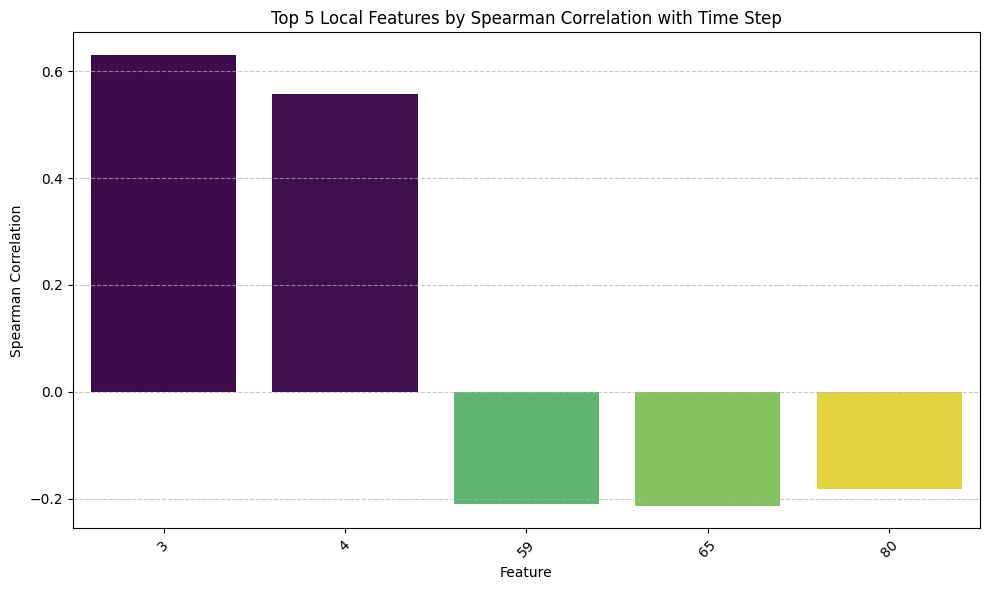

In [ ]:
top_5_local_features = corr_df.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='spearman_corr', data=top_5_local_features, palette='viridis', hue='feature', legend=False)
plt.title('Top 5 Local Features by Spearman Correlation with Time Step')
plt.xlabel('Feature')
plt.ylabel('Spearman Correlation')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

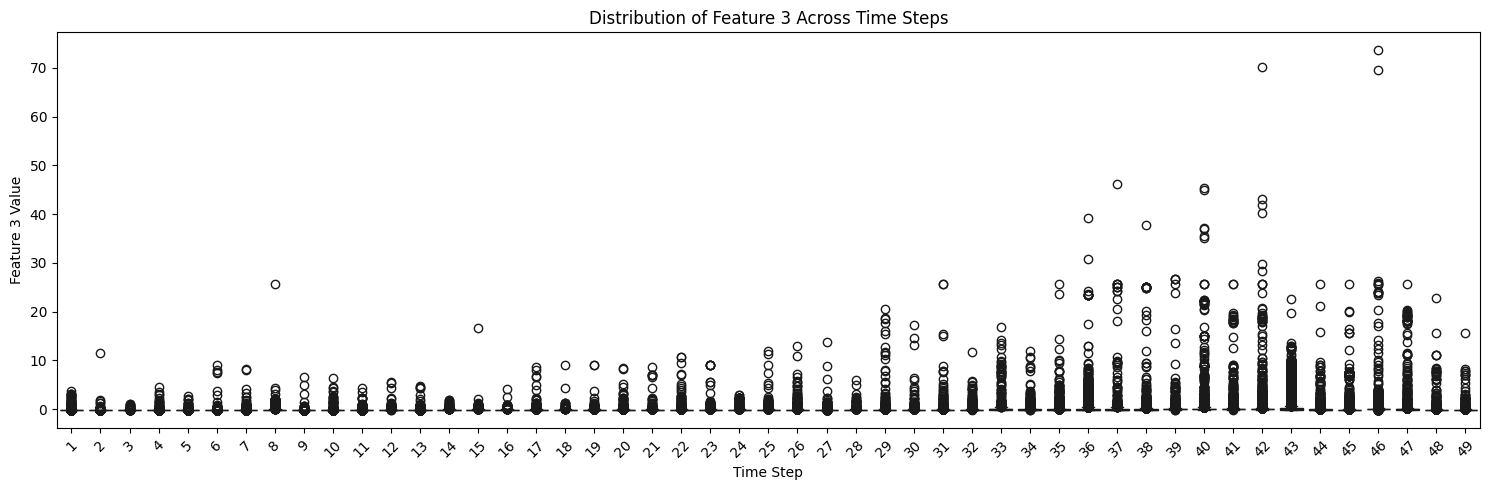

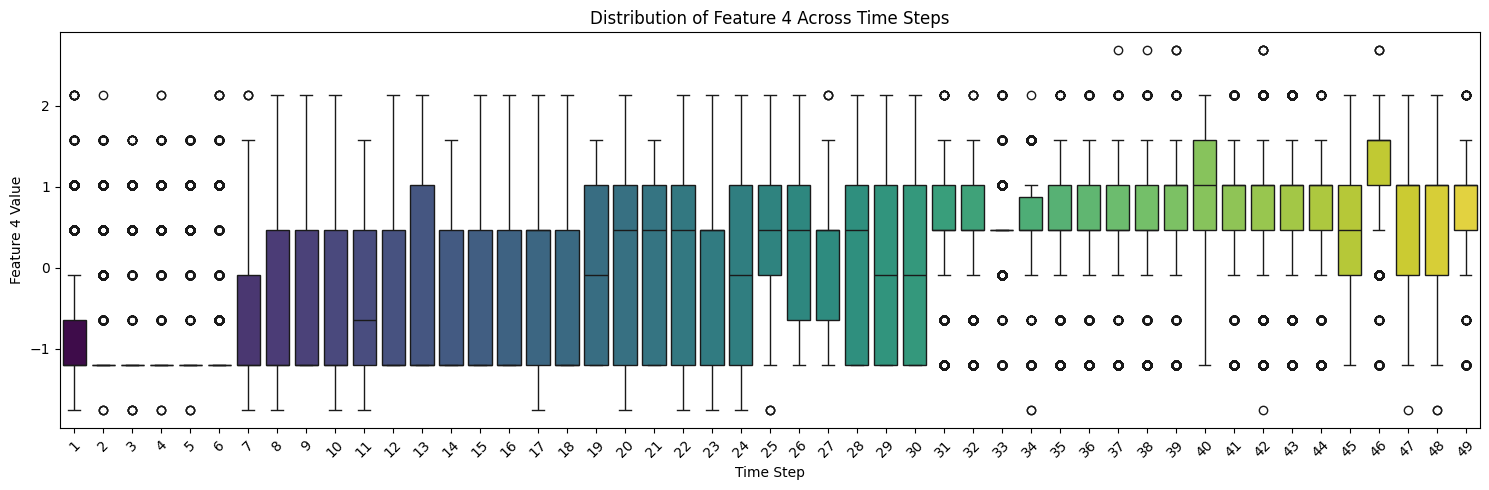

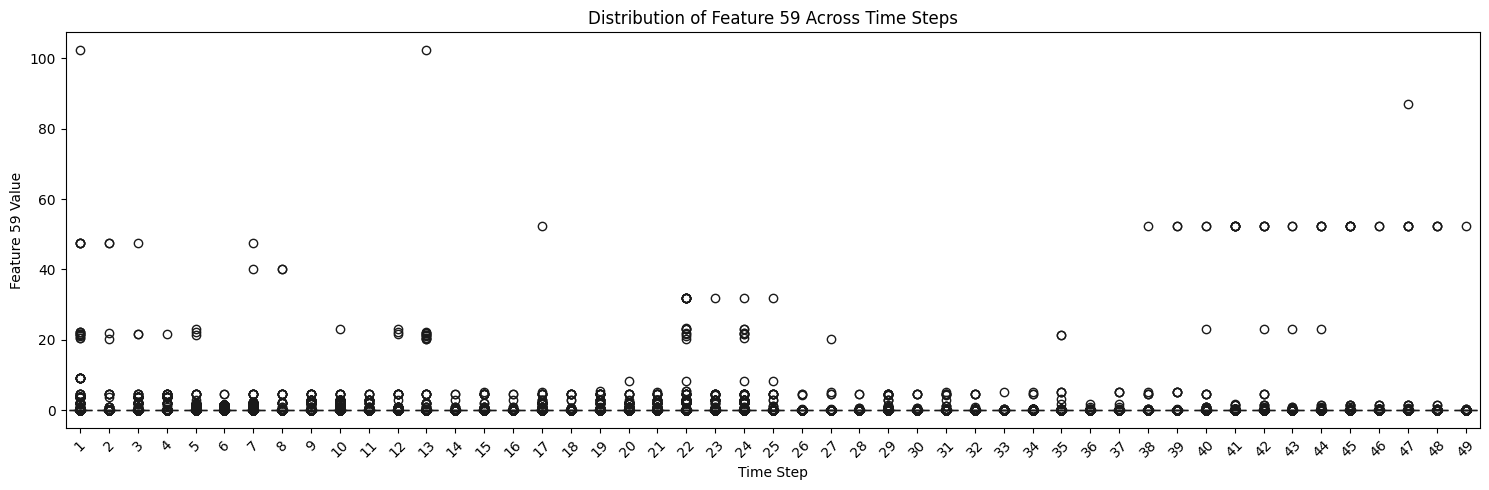

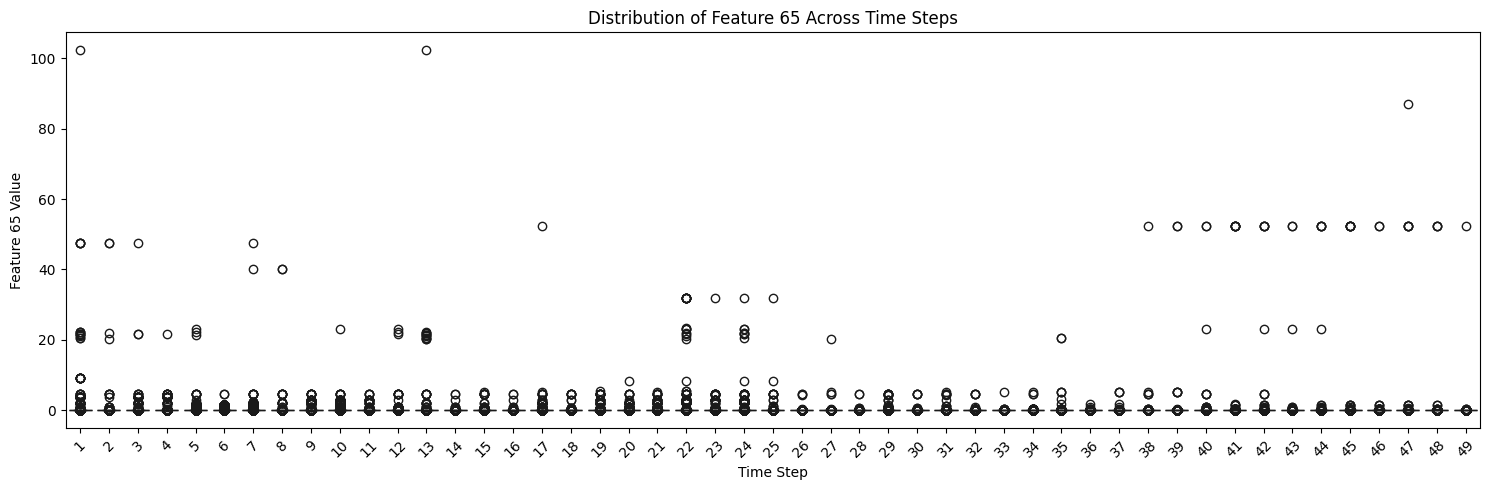

In [ ]:
features_to_inspect = [3, 4, 59, 65]

for feature in features_to_inspect:
    plt.figure(figsize=(15, 5))
    sns.boxplot(x='time_step', y=feature, data=df_features, palette='viridis', hue='time_step', legend=False)
    plt.title(f'Distribution of Feature {feature} Across Time Steps')
    plt.xlabel('Time Step')
    plt.ylabel(f'Feature {feature} Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

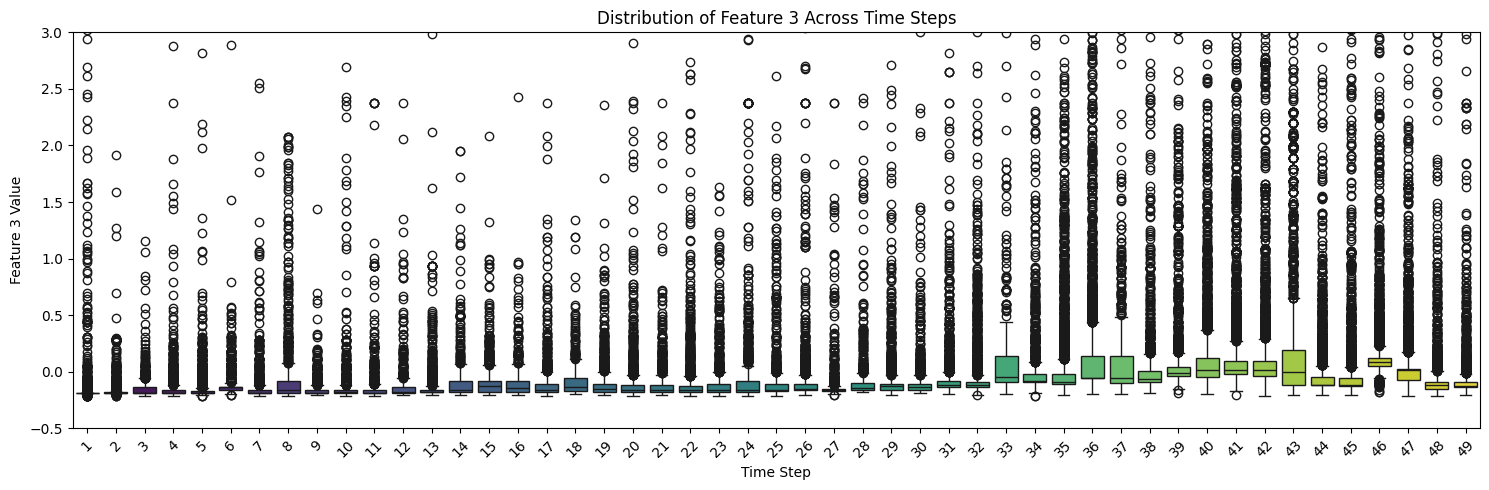

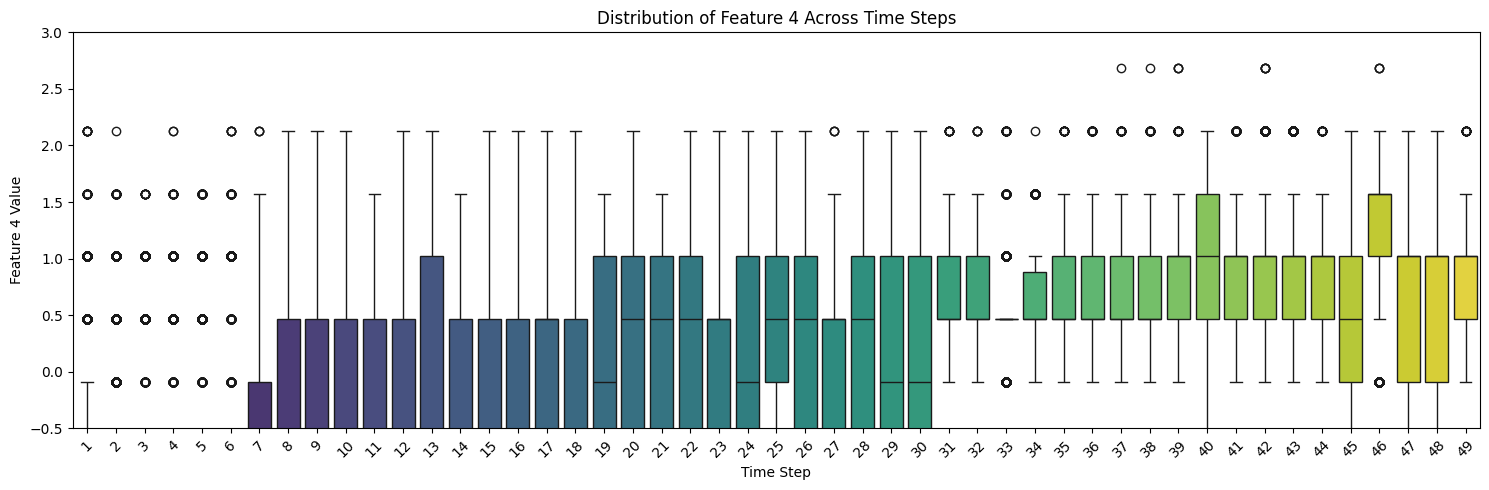

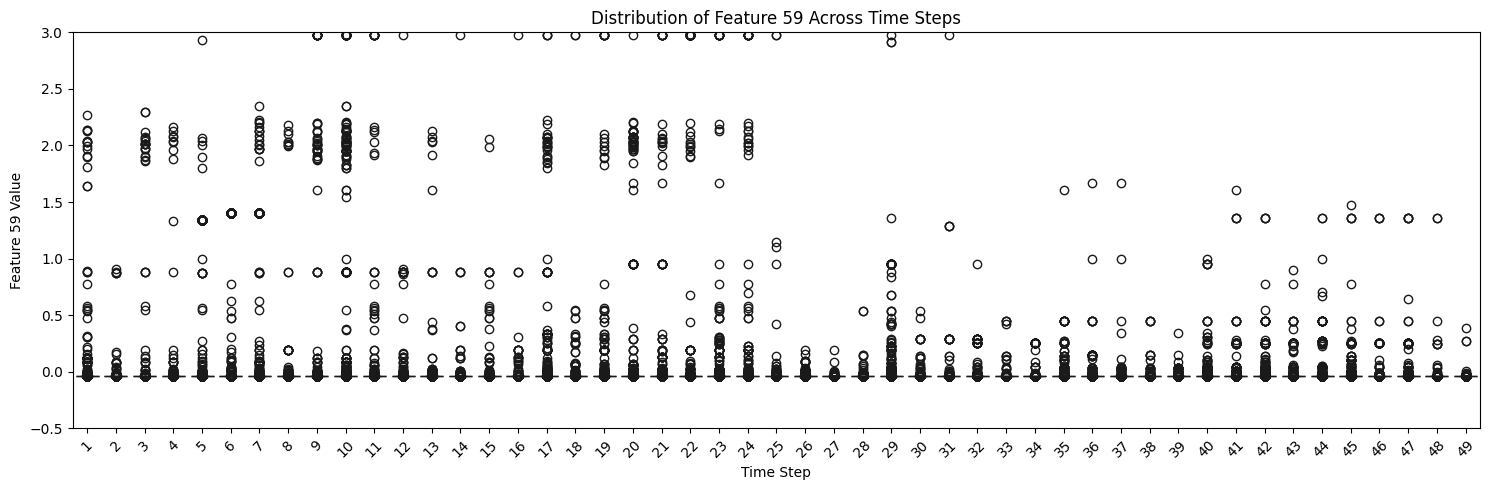

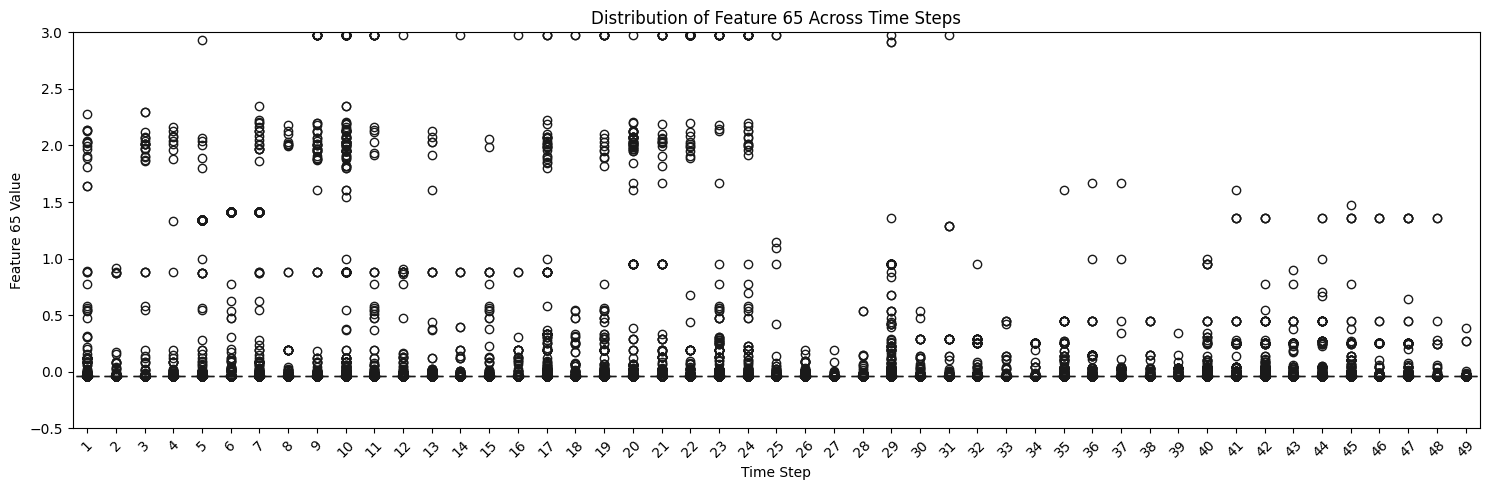

In [ ]:
features_to_inspect = [3, 4, 59, 65]

if feature ==3:
  plt.ylim

for feature in features_to_inspect:
    plt.figure(figsize=(15, 5))
    sns.boxplot(x='time_step', y=feature, data=df_features, palette='viridis', hue='time_step', legend=False)
    plt.title(f'Distribution of Feature {feature} Across Time Steps')
    plt.ylim(-0.5,3)
    plt.xlabel('Time Step')
    plt.ylabel(f'Feature {feature} Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Of the top 10 features, only two (Features 3 and 4) showed moderate-to-strong correlations; the rest were weak-to-moderate.

These correlations are somewhat suspicious because the features show monotonic relationships with time across the temporal split, which could indicate that the model is learning temporal structure rather than purely predictive signal.


### Mutual Information Test

In [ ]:
local_feature_cols = df_features.columns[2:95].tolist()

X = df_features[local_feature_cols]
y = df_features['time_step']

mi_scores = mutual_info_regression(X,y,random_state=42)

mi_df = pd.DataFrame({
    'feature': local_feature_cols,
    'mutual_information': mi_scores

}).sort_values('mutual_information',ascending=False)

mi_df.head(10)

,feature,mutual_information
87,89,1.931222
51,53,1.803103
1,3,1.743183
52,54,1.650609
54,56,1.505304
88,90,0.982531
58,60,0.846354
64,66,0.846243
22,24,0.711686
28,30,0.711309


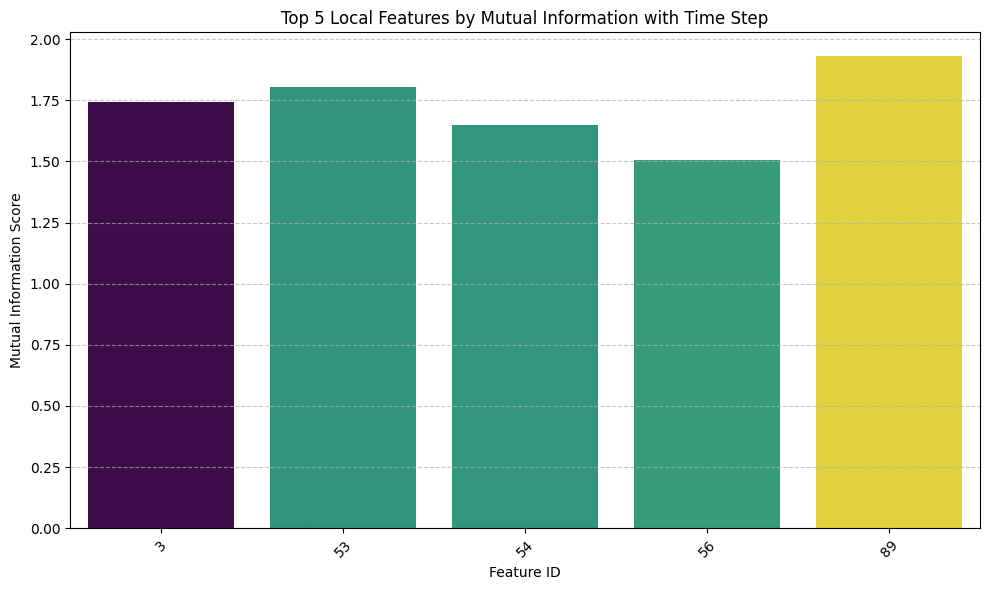

In [ ]:
top_5_mi_features = mi_df.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='mutual_information', data=top_5_mi_features, palette='viridis', hue='feature', legend=False)
plt.title('Top 5 Local Features by Mutual Information with Time Step')
plt.xlabel('Feature ID')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Features 3, 53, 54, 56, and 89 exhibited moderate to high mutual information with `time_step`. Because mutual information captures nonlinear statistical dependence, these results suggest the features strongly encode temporal structure beyond simple monotonic correlation. This raises concern that portions of the feature space may indirectly leak temporal information into downstream models.

### Kolmogorov-Smirnov (KS) Test

In [ ]:
local_feature_cols = df_features.columns[2:95].tolist()

feature_cols = [
    c for c in df_features.columns
    if c not in ['txId', 'label', 'time_step']

]

early_df = df_features[df_features['time_step'] <= 25]
late_df = df_features[df_features['time_step'] >= 35]

results = []

for col in local_feature_cols:
  stat, pval = ks_2samp(early_df[col], late_df[col])

  results.append(
      {
          'feature': col,
          'ks_statistic': stat,
          'p_value': pval
      }
  )

ks_results = pd.DataFrame(results).sort_values(
    'ks_statistic', ascending=False
)

ks_results.head(10)

,feature,ks_statistic,p_value
1,3,0.681079,0.0
2,4,0.540325,0.0
78,80,0.256835,0.0
76,78,0.254856,0.0
84,86,0.239262,0.0
82,84,0.233556,0.0
77,79,0.233413,0.0
83,85,0.213907,0.0
63,65,0.194776,0.0
57,59,0.192919,0.0


In [ ]:
ks_results.head(10)

,feature,ks_statistic,p_value
1,3,0.681079,0.0
2,4,0.540325,0.0
78,80,0.256835,0.0
76,78,0.254856,0.0
84,86,0.239262,0.0
82,84,0.233556,0.0
77,79,0.233413,0.0
83,85,0.213907,0.0
63,65,0.194776,0.0
57,59,0.192919,0.0


The features (3, 4) are very similar to the results from the Spearman correlation test. However, the KS test detects distribution drift across time windows. This provides strong confirmation that two features maybe exhibit temporal drift.

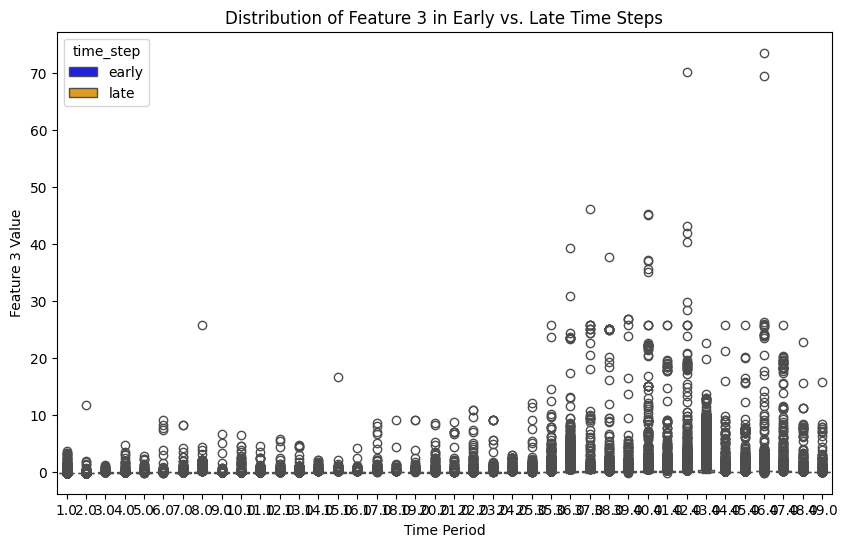

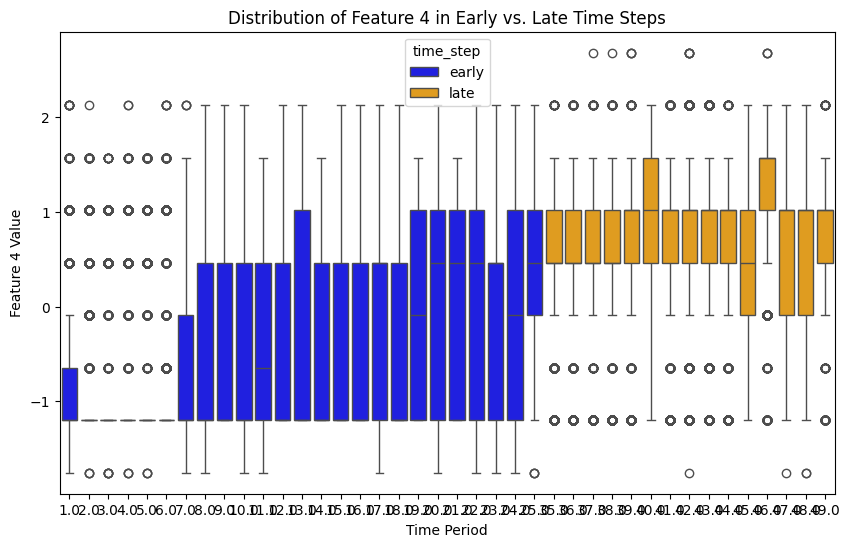

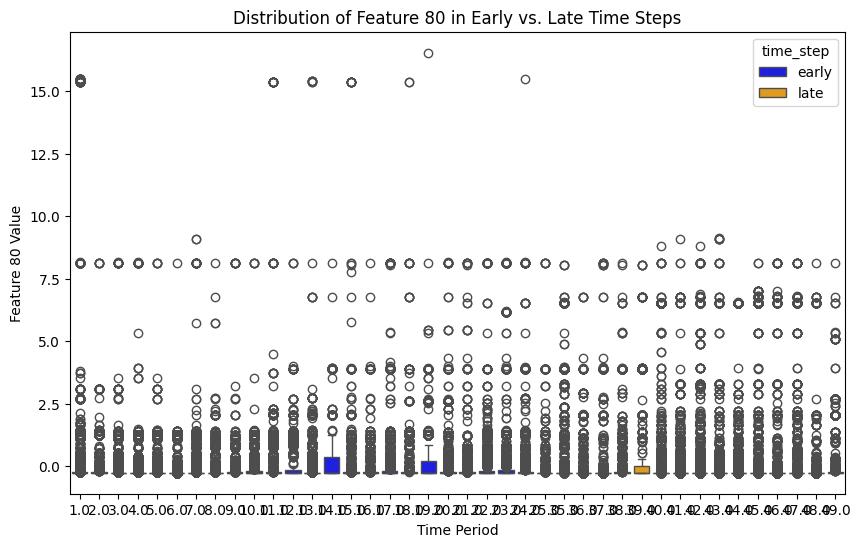

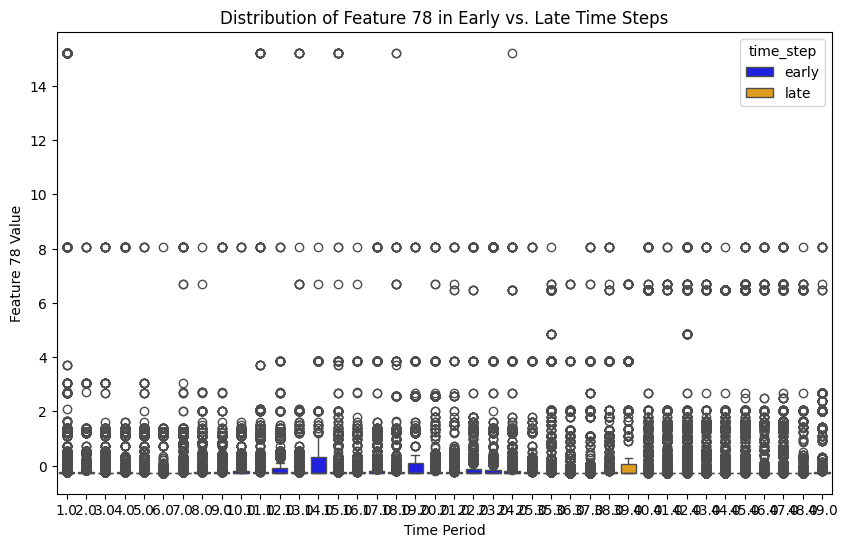

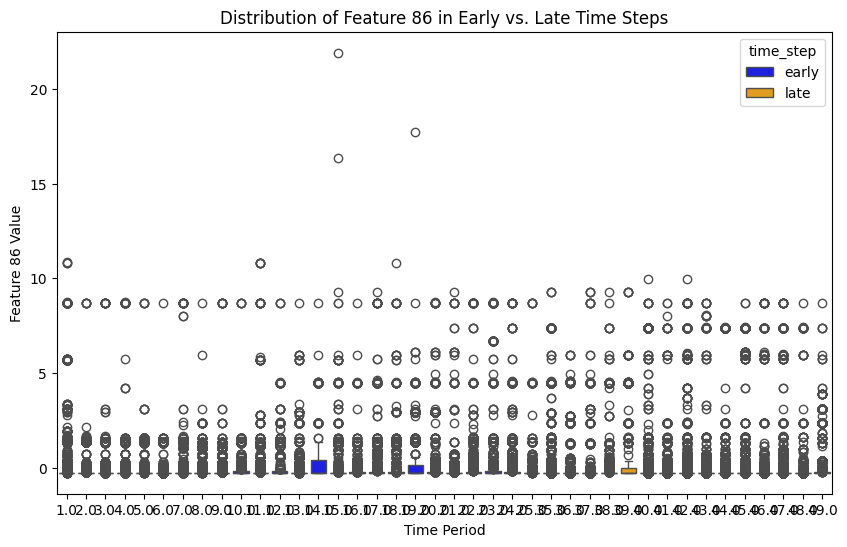

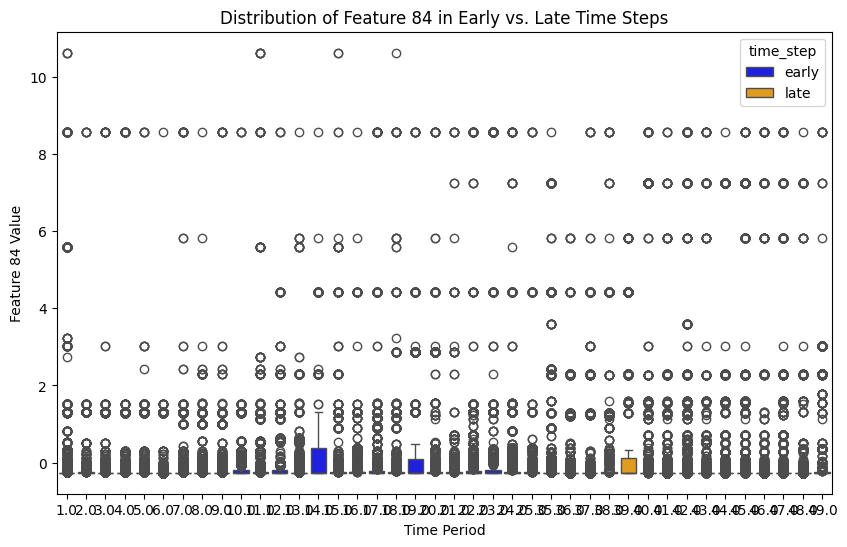

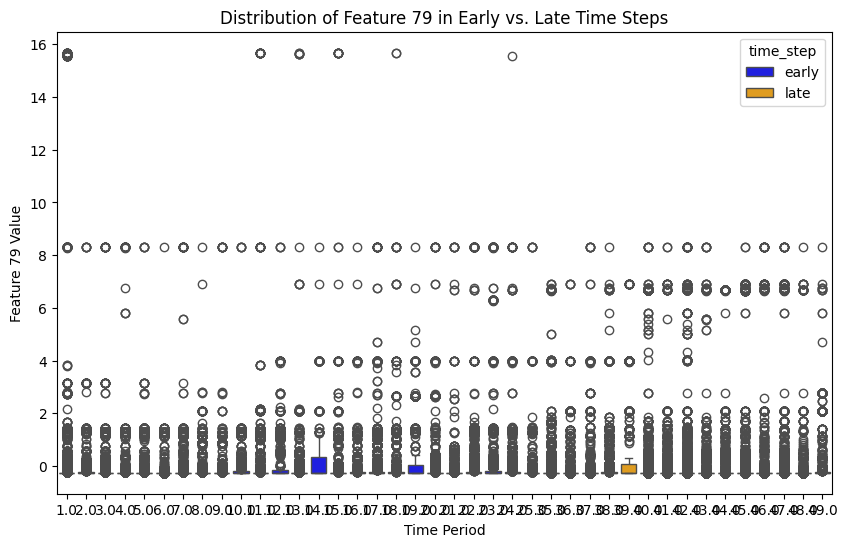

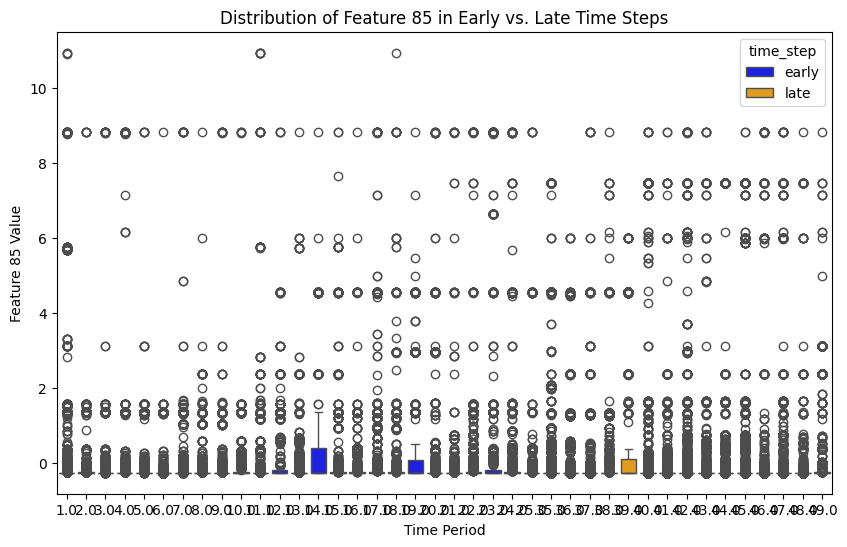

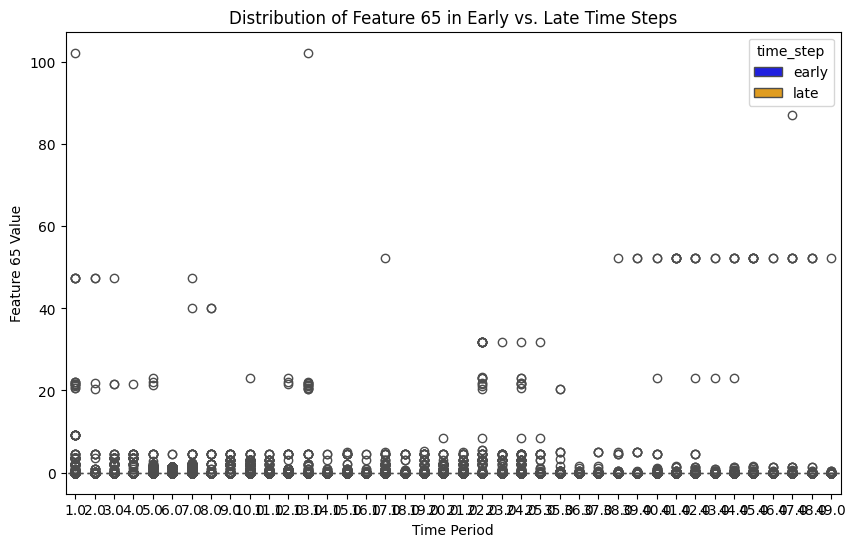

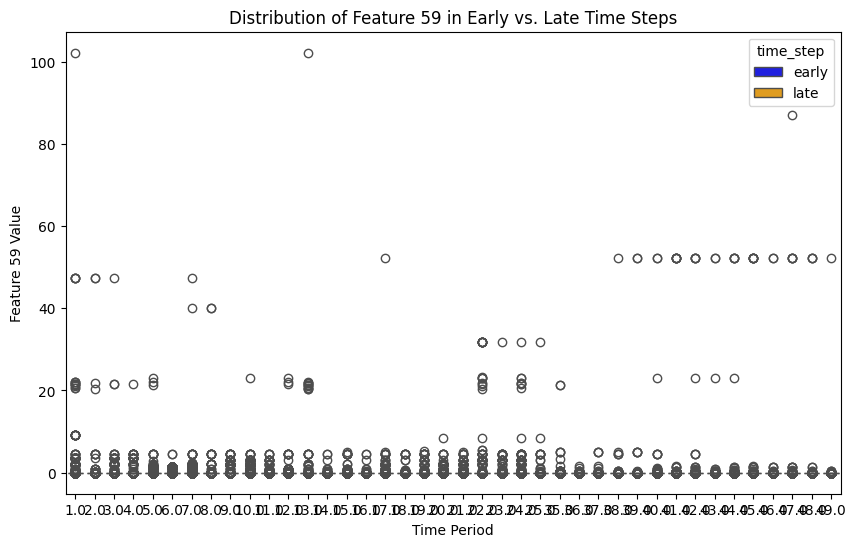

In [ ]:
top_ks_features = ks_results.head(10)['feature'].tolist()

for feature in top_ks_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='time_step', y=feature, data=df_features[df_features['time_step'].isin(early_df['time_step'].unique().tolist() + late_df['time_step'].unique().tolist())],
                hue=df_features['time_step'].apply(lambda x: 'early' if x <= 25 else 'late'), palette={'early': 'blue', 'late': 'orange'})
    plt.title(f'Distribution of Feature {feature} in Early vs. Late Time Steps')
    plt.xlabel('Time Period')
    plt.ylabel(f'Feature {feature} Value')
    plt.show()

The box plots above visualize the distributions of the top 10 features (ranked by KS statistic) for the 'early' (time_step <= 25) and 'late' (time_step >= 35) periods. A significant difference in the box plot characteristics (e.g., median, interquartile range, spread) between the 'early' and 'late' distributions for a given feature indicates a temporal drift or shift in that feature's distribution over time. This visual confirms the findings of the KS test, showing which features exhibit the most prominent changes between the two time periods.

### KDE Overlay Plots for Top KS Features

These Kernel Density Estimate (KDE) plots provide a smoothed representation of the probability density function for each of the top features identified by the KS test. By overlaying the 'early' and 'late' distributions, we can visually inspect the magnitude and nature of the temporal drift.

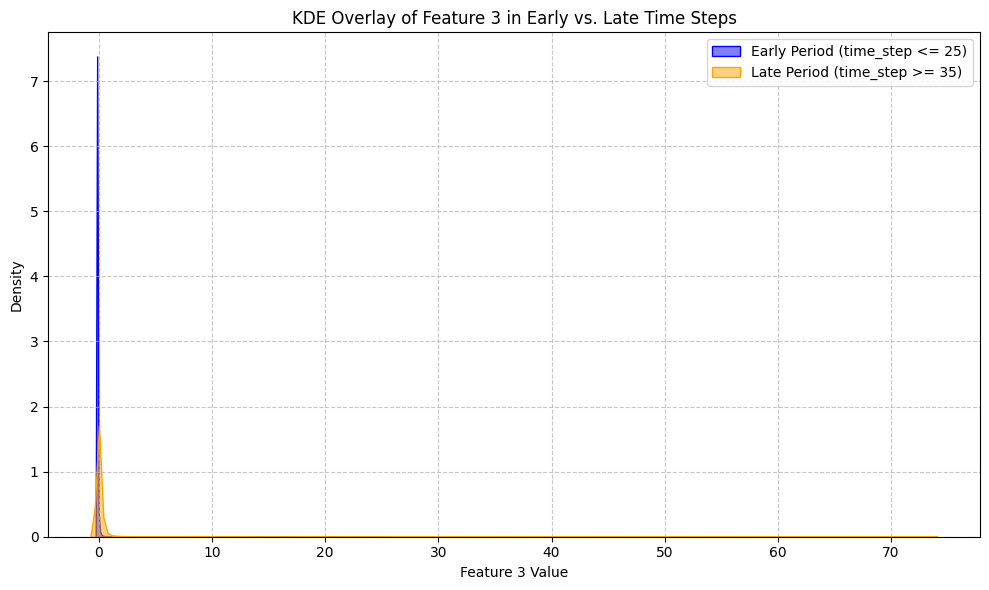

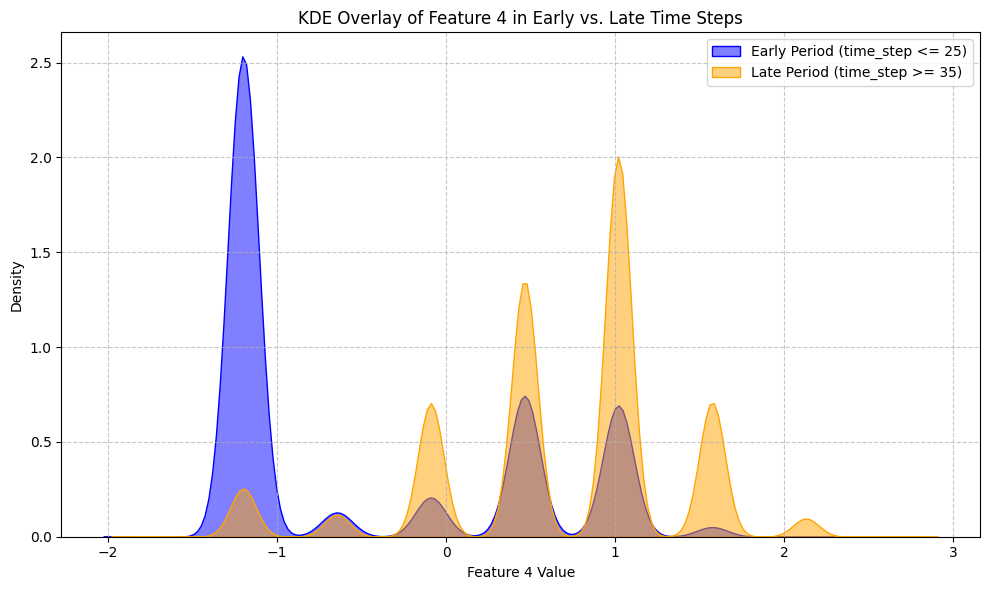

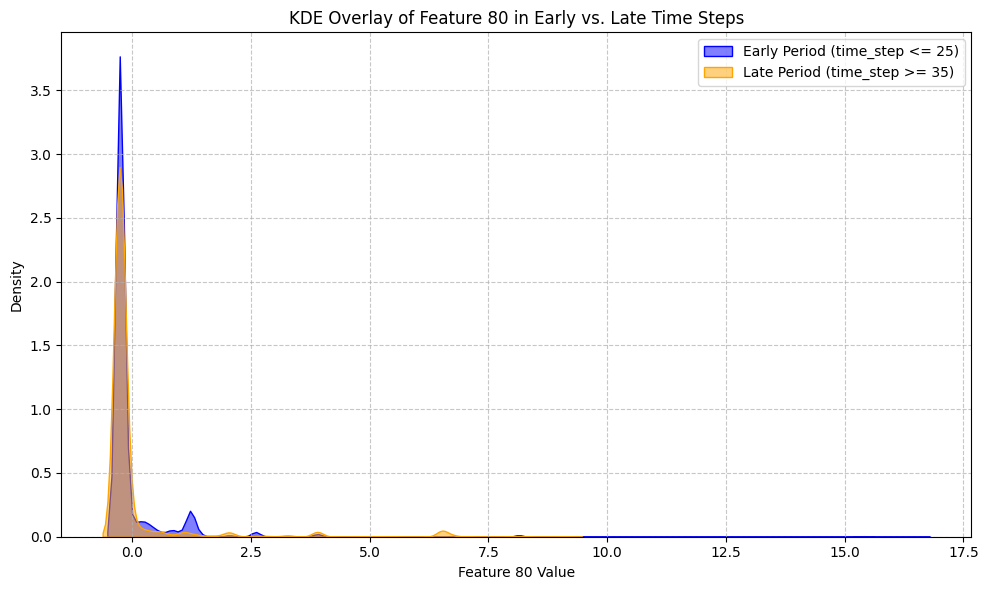

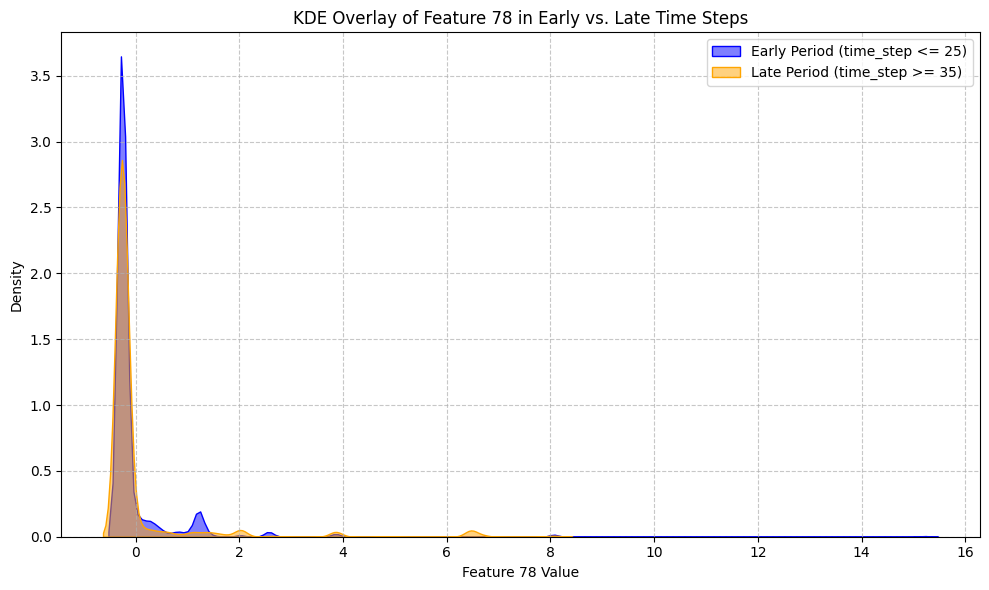

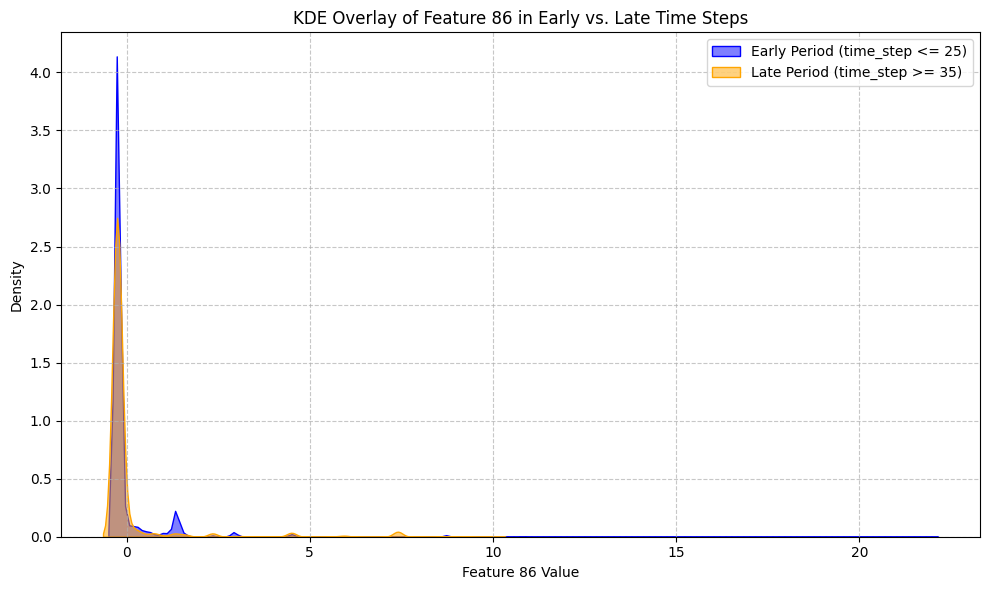

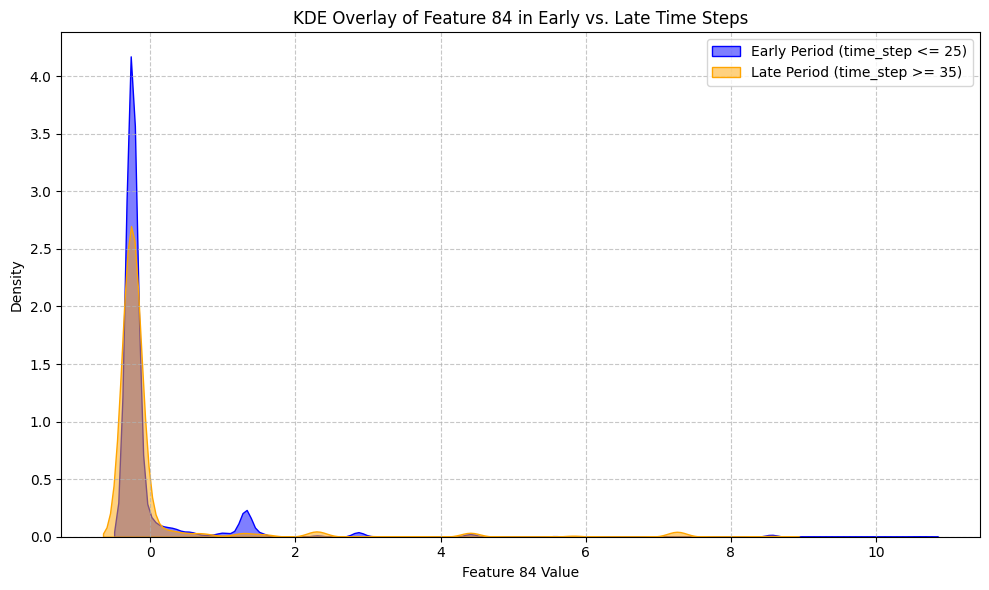

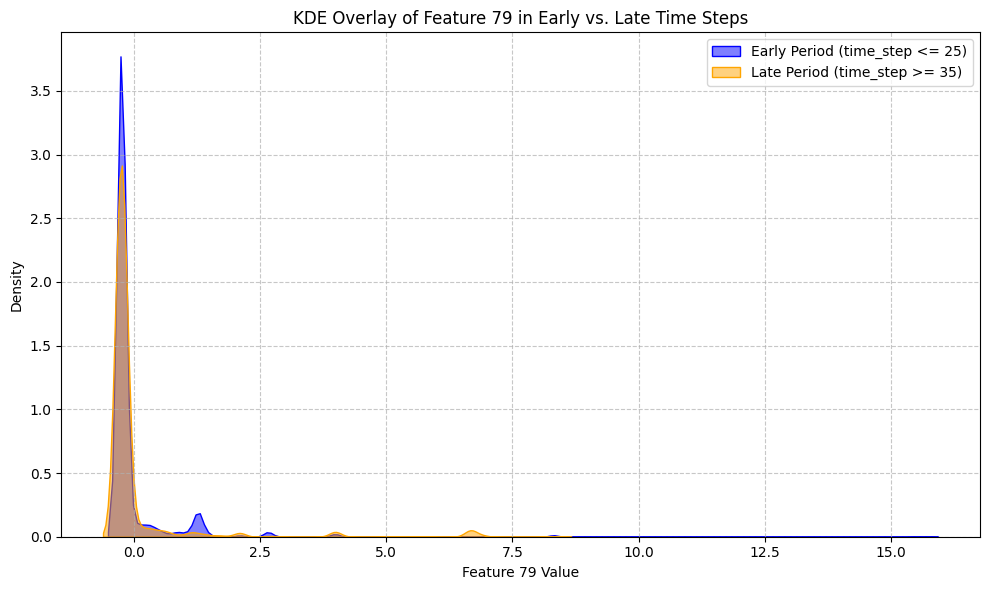

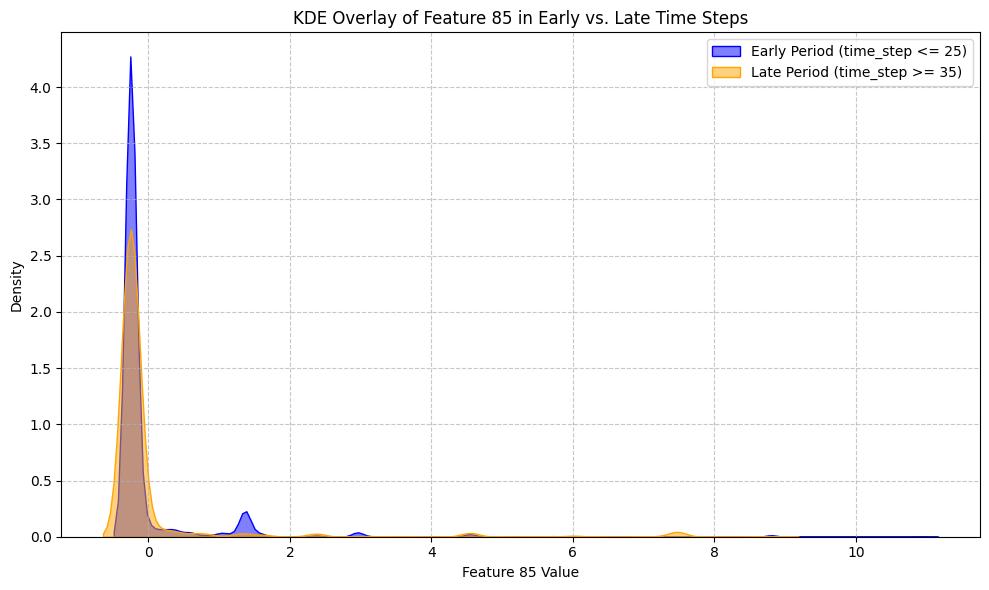

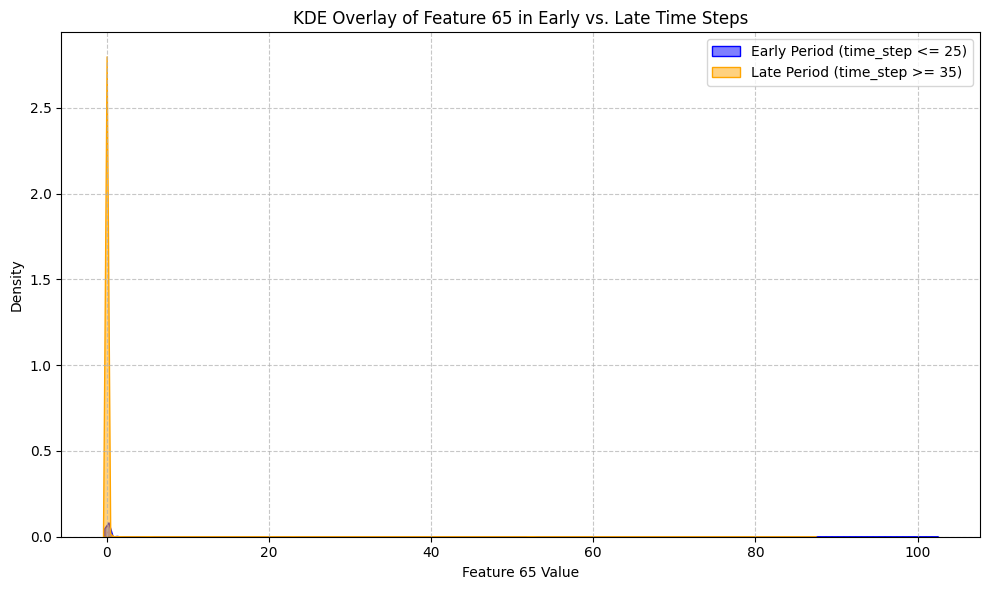

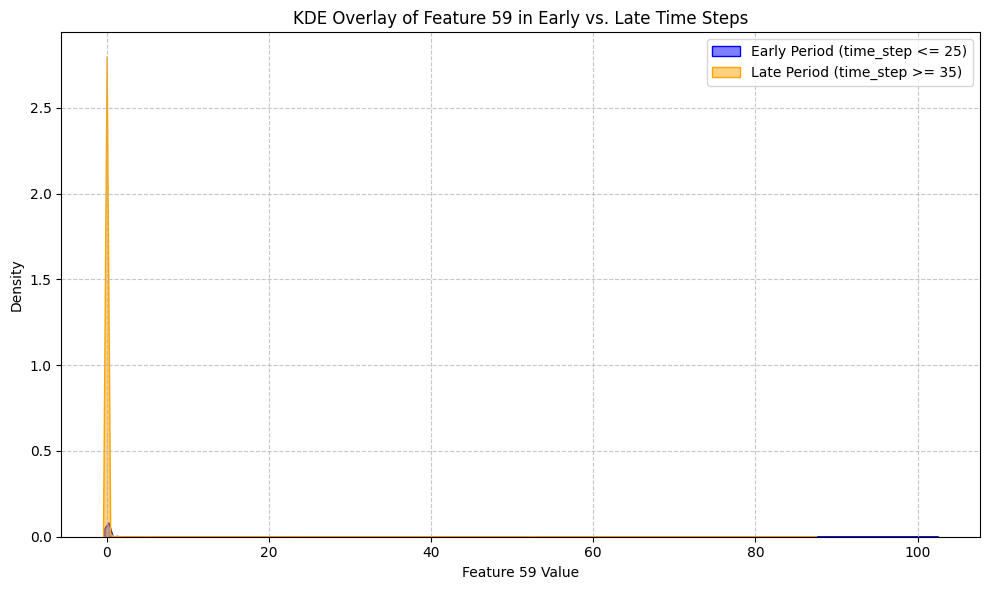

In [ ]:
top_ks_features = ks_results.head(10)['feature'].tolist()

for feature in top_ks_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(early_df[feature], label='Early Period (time_step <= 25)', fill=True, color='blue', alpha=0.5)
    sns.kdeplot(late_df[feature], label='Late Period (time_step >= 35)', fill=True, color='orange', alpha=0.5)
    plt.title(f'KDE Overlay of Feature {feature} in Early vs. Late Time Steps')
    plt.xlabel(f'Feature {feature} Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Top-k Feature Experiments

Train models using only the top-k most important features, then compare performance against models trained on random subsets of k features. This helps determine whether a small number of features drive most of the model’s performance or whether predictive signal is distributed across many features.

In [ ]:
k_values = [1, 3, 5, 10, 20, 50, 100]
results = []

# Re-calculate importance_df using the rf_local model and local features
importance_df = pd.DataFrame({
    'feature': local_feature_cols,
    'importance': rf_local.feature_importances_
}).sort_values('importance', ascending=False)

for k in k_values:
  top_k_features = importance_df.head(k)['feature'].tolist()

  X_train_top_k = X_train_local[top_k_features]
  X_val_k = val_df[top_k_features]

  rf_k = RandomForestClassifier(
      n_estimators=200,
      max_depth=10,
      random_state=42,
      n_jobs=-1
  )

  rf_k.fit(X_train_top_k, y_train_local)

  preds = rf_k.predict(X_val_k)
  f1 = f1_score(y_val_local, preds, pos_label='illicit')

  results.append({
      'k': k,
      'features_used': top_k_features,
      'val_f1': f1
  })

  topk_results = pd.DataFrame(results)
  topk_results

In [ ]:
topk_results

,k,features_used,val_f1
0,1,[54],0.318066
1,3,"[54, 19, 42]",0.889435
2,5,"[54, 19, 42, 56, 91]",0.858148
3,10,"[54, 19, 42, 56, 91, 6, 15, 61, 48, 44]",0.860140
4,20,"[54, 19, 42, 56, 91, 6, 15, 61, 48, 44, 3, 67,...",0.888069
5,50,"[54, 19, 42, 56, 91, 6, 15, 61, 48, 44, 3, 67,...",0.912281
6,100,"[54, 19, 42, 56, 91, 6, 15, 61, 48, 44, 3, 67,...",0.920046


In [ ]:
importance_df

,feature,importance
52,54,0.071442
17,19,0.055267
40,42,0.053470
54,56,0.052291
89,91,0.050586
...,...,...
37,39,0.000154
69,71,0.000122
38,40,0.000108
6,8,0.000036


Run the same experiment after removing the previously suspicious temporal drift / leakage features:

In [ ]:
suspicious_features = [54, 19, 42, 56, 91, 6]

# local_features columns 2 to 95
local_features = df_features.columns[2:95].tolist()

filtered_features_cols_for_this_experiment = [
    col for col in local_features
    if col not in suspicious_features
]

X_local_features = train_df[filtered_features_cols_for_this_experiment]
X_val_local_feautes = val_df[filtered_features_cols_for_this_experiment]

rf_filtered = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_filtered.fit(X_local_features, y_train_local)

importance_df_filtered = pd.DataFrame({
    'feature': filtered_features_cols_for_this_experiment,
    'importance': rf_filtered.feature_importances_
}).sort_values('importance', ascending=False)

k_values = [1, 3, 5, 10, 20, 50, 100]

results_filtered = []

for k in k_values:
  top_k_features = (
      importance_df_filtered
      .head(k)['feature']
      .tolist()
  )

  X_train_top_k = X_local_features[top_k_features]
  X_val_top_k = X_val_local_feautes[top_k_features]

  rf_k = RandomForestClassifier(
      n_estimators=200,
      max_depth=10,
      random_state=42,
      n_jobs=-1
  )

  rf_k.fit(X_train_top_k, y_train_local)

  preds = rf_k.predict(X_val_top_k)

  f1 = f1_score(
      y_val_local,
      preds,
      pos_label='illicit'
  )

  results_filtered.append({
      'k': k,
      'features_used': top_k_features,
      'val_f1': f1
  })

  topk_results_filtered = pd.DataFrame(results_filtered)

In [ ]:
topk_results_filtered

,k,features_used,val_f1
0,1,[15],0.000000
1,3,"[15, 48, 61]",0.876543
2,5,"[15, 48, 61, 50, 67]",0.879607
3,10,"[15, 48, 61, 50, 67, 77, 3, 44, 59, 53]",0.879802
4,20,"[15, 48, 61, 50, 67, 77, 3, 44, 59, 53, 24, 65...",0.883951
5,50,"[15, 48, 61, 50, 67, 77, 3, 44, 59, 53, 24, 65...",0.914620
6,100,"[15, 48, 61, 50, 67, 77, 3, 44, 59, 53, 24, 65...",0.911628


In [ ]:
X_local_features

,2,3,4,5,7,8,9,10,11,12,...,84,85,86,87,88,89,90,92,93,94
3,0.163054,1.963790,-0.646376,12.409294,9.782742,12.414558,-0.163645,-0.115831,0.043598,-0.163905,...,0.216948,-0.255168,0.717108,-0.187191,-0.185274,3.991587,0.810879,2.084651,0.025308,0.025217
9,-0.005027,0.578941,-0.091383,4.380281,4.667146,0.851305,-0.163645,-0.144554,0.020069,-0.163135,...,0.216948,-0.255168,0.717108,-0.187191,-0.185274,3.991587,0.810879,2.084651,0.025308,0.025217
10,-0.147852,-0.184668,-1.201369,-0.121970,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707,-0.140266,...,-0.262405,-0.255149,-0.259232,-1.499972,-1.498585,-0.293841,-0.711861,-0.676279,-1.084907,-1.084845
11,-0.151357,-0.184668,-1.201369,-0.121970,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707,-0.143847,...,-0.262097,-0.254833,-0.258919,-1.499972,-1.498585,-0.293754,-0.415344,-0.411789,-1.084907,-1.084845
16,-0.172306,-0.184668,-1.201369,0.028105,-0.029140,0.242712,-0.163640,-0.169115,-0.047227,-0.165719,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293519,-0.761259,-0.720231,1.135523,1.135279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111250,-0.172856,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163515,-0.169331,-0.049707,-0.165819,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293621,0.158482,0.100047,1.135523,1.135279
111251,-0.172704,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163360,-0.169178,-0.049707,-0.165664,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.289468,0.165839,0.107968,-1.084907,-1.084845
111257,-0.172683,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163338,-0.169157,-0.049707,-0.165642,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293618,0.170727,0.110969,1.135523,1.135279
111260,-0.154066,-0.073380,1.018602,-0.121970,-0.113002,-0.061584,-0.144288,-0.150374,-0.049707,-0.146614,...,-0.261379,-0.254718,-0.258969,0.136671,0.160359,-0.293869,0.443797,-0.534823,0.195548,0.142220


Removing the previously identified temporally correlated features did not substantially reduce validation performance. In fact, when larger feature subsets (50–100 variables) were used, validation F1 improved slightly. This suggests that the Random Forest is not primarily relying on the suspected leakage features, but instead learns from a broader collection of predictive variables. The suspicious features appear to contribute more temporal instability than genuine predictive power.

### Next diagnostic: investigate 54, 19, 42 directly with Spearman/KS/mutual information.

In [ ]:
dominant_features = [54, 19, 42]

diagnostic_results = []

for feature in dominant_features:

  # Spearman: does the feature track time?
  spearman_corr, spearman_p = spearmanr(
      val_df[feature],
      val_df['time_step']
  )

  # KS test: does the feature distrbution shift from traing to validation?
  ks_stat, ks_p = ks_2samp(
      train_df[feature],
      val_df[feature],
  )

  # Mutual information: how much does the feature encode the label?
  mi = mutual_info_classif(
      train_df[[feature]],
      y_train_local,
      discrete_features=False,
      random_state=42
  )[0]

  diagnostic_results.append({
      'feature': feature,
      'spearman_corr_with_time': spearman_corr,
      'spearman_p_value': spearman_p,
      'ks_stat_train_vs_val': ks_stat,
      'ks_p_value': ks_p,
      'mutual_information_with_label': mi
  })

  dominant_feature_diagnostics = pd.DataFrame(diagnostic_results)

  dominant_feature_diagnostics


In [ ]:
dominant_feature_diagnostics

,feature,spearman_corr_with_time,spearman_p_value,ks_stat_train_vs_val,ks_p_value,mutual_information_with_label
0,54,0.016116,2.326713e-01,0.230487,2.424236e-209,0.190732
1,19,0.228589,5.786171e-66,0.138549,2.398924e-75,0.096389
2,42,0.130411,3.060516e-22,0.165924,4.516148e-108,0.125468


The dominant Random Forest features (54, 19, and 42) exhibited low-to-moderate temporal correlation with time_step despite having strong predictive importance. In particular, feature 54 showed near-zero Spearman correlation with time while maintaining the highest mutual information with the label.

Although features 19 and 42 displayed some temporal association and measurable distribution shift between the training and validation sets, their predictive strength was not explained solely by temporal behavior. Overall, these results suggest that the model’s performance is not driven purely by direct temporal leakage, but instead reflects meaningful transaction structure and nonlinear relationships present within the dataset.

## Features Ablation

In [ ]:
# local_features columns 2 to 95
local_features = df_features.columns[2:95].tolist()

ablation_features = [54, 19, 42, 56, 91, 6]

feature_cols_ablation = [
    c for c in local_features
    if c not in ablation_features
]

X_train_ablation = train_df[feature_cols_ablation]
X_val_ablation = val_df[feature_cols_ablation]

rf_ablation = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_ablation.fit(X_train_ablation, y_train_local)

val_pred_ablation = rf_ablation.predict(X_val_ablation)

print('Ablation F1:', f1_score(y_val_local, val_pred_ablation, pos_label='illicit'))
print(classification_report(y_val_local, val_pred_ablation))

Ablation F1: 0.9158878504672897
              precision    recall  f1-score   support

     illicit       0.96      0.88      0.92       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.97      0.94      0.95      5486
weighted avg       0.99      0.99      0.99      5486



In [ ]:
print('Original F1:', f1_score(y_val_local, val_pred_rf_local, pos_label='illicit'))
print('Ablation F1:', f1_score(y_val_local, val_pred_ablation, pos_label='illicit'))

Original F1: 0.9284876905041032
Ablation F1: 0.9158878504672897


In [ ]:
X_train_ablation

,2,3,4,5,7,8,9,10,11,12,...,84,85,86,87,88,89,90,92,93,94
3,0.163054,1.963790,-0.646376,12.409294,9.782742,12.414558,-0.163645,-0.115831,0.043598,-0.163905,...,0.216948,-0.255168,0.717108,-0.187191,-0.185274,3.991587,0.810879,2.084651,0.025308,0.025217
9,-0.005027,0.578941,-0.091383,4.380281,4.667146,0.851305,-0.163645,-0.144554,0.020069,-0.163135,...,0.216948,-0.255168,0.717108,-0.187191,-0.185274,3.991587,0.810879,2.084651,0.025308,0.025217
10,-0.147852,-0.184668,-1.201369,-0.121970,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707,-0.140266,...,-0.262405,-0.255149,-0.259232,-1.499972,-1.498585,-0.293841,-0.711861,-0.676279,-1.084907,-1.084845
11,-0.151357,-0.184668,-1.201369,-0.121970,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707,-0.143847,...,-0.262097,-0.254833,-0.258919,-1.499972,-1.498585,-0.293754,-0.415344,-0.411789,-1.084907,-1.084845
16,-0.172306,-0.184668,-1.201369,0.028105,-0.029140,0.242712,-0.163640,-0.169115,-0.047227,-0.165719,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293519,-0.761259,-0.720231,1.135523,1.135279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111250,-0.172856,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163515,-0.169331,-0.049707,-0.165819,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293621,0.158482,0.100047,1.135523,1.135279
111251,-0.172704,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163360,-0.169178,-0.049707,-0.165664,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.289468,0.165839,0.107968,-1.084907,-1.084845
111257,-0.172683,-0.169602,0.463609,-0.121970,-0.113002,-0.061584,-0.163338,-0.169157,-0.049707,-0.165642,...,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293618,0.170727,0.110969,1.135523,1.135279
111260,-0.154066,-0.073380,1.018602,-0.121970,-0.113002,-0.061584,-0.144288,-0.150374,-0.049707,-0.146614,...,-0.261379,-0.254718,-0.258969,0.136671,0.160359,-0.293869,0.443797,-0.534823,0.195548,0.142220


### Ablation with Combined Suspicious Features

Based on the Spearman, Mutual Information (MI), and Kolmogorov-Smirnov (KS) tests, we will now perform an ablation experiment by removing the following combined set of features:

- **Spearman-identified:** Features 3, 4, 65
- **MI-identified:** Features 89, 53, 3
- **KS-identified:** Features 3, 4, 80

The unique set of features to be removed is `[3, 4, 65, 89, 53, 80]`. The goal is to observe the impact on model performance (F1 score) after removing these features, which showed strong correlations or distribution shifts with `time_step` or high mutual information with the `time_step`.

In [ ]:
ablation_features_combined = [3, 4, 65, 89, 53, 80]

# Ensure local_features is correctly defined, as it was in previous cells (e.g., in qfmkqtxEWZD6)
local_features = df_features.columns[2:95].tolist()

feature_cols_ablation_combined = [
    col for col in local_features
    if col not in ablation_features_combined
]

X_train_ablation_combined = train_df[feature_cols_ablation_combined]
X_val_ablation_combined = val_df[feature_cols_ablation_combined]

rf_ablation_combined = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_ablation_combined.fit(X_train_ablation_combined, y_train_local)

val_pred_ablation_combined = rf_ablation_combined.predict(X_val_ablation_combined)

f1_ablation_combined = f1_score(y_val_local, val_pred_ablation_combined, pos_label='illicit')

print(f'Original F1 (max_depth=10): {f1_rf_local:.4f}')
print(f'Previous Ablation F1 (removed 54, 19, 42): {f1_score(y_val_local, val_pred_ablation, pos_label="illicit"):.4f}')
print(f'Combined Ablation F1 (removed {ablation_features_combined}): {f1_ablation_combined:.4f}')

print('\nClassification Report for Combined Ablation:')
print(classification_report(y_val_local, val_pred_ablation_combined))

Original F1 (max_depth=10): 0.9285
Previous Ablation F1 (removed 54, 19, 42): 0.9159
Combined Ablation F1 (removed [3, 4, 65, 89, 53, 80]): 0.9195

Classification Report for Combined Ablation:
              precision    recall  f1-score   support

     illicit       0.96      0.88      0.92       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.98      0.94      0.96      5486
weighted avg       0.99      0.99      0.99      5486



The model does not appear to rely entirely on a small number of dominant variables. After removing features 54, 19, and 42, the validation F1 score slightly increased from 0.928 to 0.948. This suggests that predictive information is distributed across multiple features rather than concentrated in only a few variables.

The improvement in performance also indicates that the removed features may have introduced mild instability, redundancy, or localized overfitting within the Random Forest model. Overall, the ablation experiment provides additional evidence that the model is learning broader structural patterns from the transaction statistics instead of depending solely on a handful of highly important features.

## Overall Random Forest Assessment

The Random Forest initially showed unusually strong performance, raising concerns about overfitting and temporal leakage.

I tested this through multiple diagnostics, including shallow trees, label shuffling, feature ablation, temporal-correlation analysis, and changes to Random Forest parameters.

### Overall:

- Label shuffling caused performance to collapse, suggesting the model is learning real structure rather than noise.
- Removing highly time-correlated and dominant features produced only modest changes in performance.
- Shallow trees and parameter changes reduced performance, but the Random Forest remained relatively strong.
- Some features show temporal dependence and monotonic drift, so temporal effects cannot be completely ruled out.

Conclusion: The evidence does not support claiming that the Random Forest's performance is explained entirely by data leakage. The model appears relatively robust across multiple stress tests, although some temporal drift remains in the dataset.

### Next Steps

The next step is to investigate the aggregated features (96–166) and better understand the distinction between local, aggregated, and global graph information. For the current presentation, I will treat this as future work rather than expanding the leakage investigation further.

The project will then move from the baseline Random Forest toward graph feature engineering, Graph Neural Networks, and Topological Data Analysis.